# Supplier Performance & Stockout Analysis
---
## Project Overview

This notebook analyzes supplier delivery performance and its downstream impact on 
inventory stockouts using a simulated ERP-style SQLite database modelled after SAP.

The database contains 11 tables covering purchase orders, goods movements, sales orders, 
materials master data, and stock levels — representing approximately one year of 
procurement and inventory activity across 500 materials and 100 vendors.

**Business Questions Addressed:**
1. What are the overall supplier lead time patterns?
2. Which suppliers are most reliable (on-time delivery %)?
3. Is there a relationship between supplier delays and stockout events?
4. What is the estimated financial impact of supplier delays?
5. How does order quantity affect lead time?
6. Can we build a supplier scorecard combining multiple KPIs?
7. What actionable recommendations can be made to procurement?

---
*Tools: Python 3.13 · pandas · matplotlib · seaborn · sqlite3*

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Visual style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ── Database connection ──────────────────────────────────────────────────────
con = sqlite3.connect("inventory_management.db")
print("✅ Connected to inventory_management.db")

✅ Connected to inventory_management.db


### Database Exploration

Before any analysis, we verify the schema, movement type labels, and date formats.  
These are the three things most likely to break downstream queries if assumed incorrectly.

In [2]:
# ── 1. Confirm all tables are present ───────────────────────────────────────
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", con
)
print("Tables in database:")
print(tables.to_string(index=False))

Tables in database:
                  name
GoodsReceiptsAndIssues
     MaterialDocuments
        MaterialStocks
             Materials
      OrderSuggestions
PurchaseOrderDocuments
    PurchaseOrderItems
  PurchaseRequisitions
    SalesDocumentFlows
   SalesOrderDocuments
       SalesOrderItems


In [3]:
# ── 2. Confirm movement type labels (critical for all stock logic) ───────────
df_movements = pd.read_sql("""
    SELECT
        movement_type,
        COUNT(*)            AS record_count,
        SUM(quantity)       AS total_quantity
    FROM MaterialDocuments
    GROUP BY movement_type
    ORDER BY record_count DESC
""", con)

print("Movement types found:")
display(df_movements)

Movement types found:


,movement_type,record_count,total_quantity
0,Goods Issue,1036,54136.0
1,Goods Receipt,964,48723.0


In [4]:
# ── 3. Confirm date format and data range ────────────────────────────────────
df_date_check = pd.read_sql("""
    SELECT
        MIN(purchase_order_date)  AS earliest_po,
        MAX(purchase_order_date)  AS latest_po,
        COUNT(*)                  AS total_pos
    FROM PurchaseOrderDocuments
""", con)

display(df_date_check)
# Dates confirmed as YYYY-MM-DD — SQLite's JULIANDAY() and Python's pd.to_datetime()
# both handle this format natively with no conversion needed.

,earliest_po,latest_po,total_pos
0,2025-03-16,2026-03-16,1000


In [5]:
# ── 4. Check for nulls in key join columns ───────────────────────────────────
df_null_check = pd.read_sql("""
    SELECT
        'PurchaseOrderDocuments' AS tbl,
        SUM(CASE WHEN purchase_order_date IS NULL THEN 1 ELSE 0 END)       AS null_po_date,
        SUM(CASE WHEN account_number_of_vendor IS NULL THEN 1 ELSE 0 END)  AS null_vendor
    FROM PurchaseOrderDocuments
    UNION ALL
    SELECT
        'GoodsReceiptsAndIssues',
        SUM(CASE WHEN posting_date_in_the_document IS NULL THEN 1 ELSE 0 END),
        SUM(CASE WHEN purchase_document_number IS NULL THEN 1 ELSE 0 END)
    FROM GoodsReceiptsAndIssues
""", con)

print("Null check on critical join columns:")
display(df_null_check)

Null check on critical join columns:


,tbl,null_po_date,null_vendor
0,PurchaseOrderDocuments,0,0
1,GoodsReceiptsAndIssues,0,0


---
## Question 1: What Are the Overall Supplier Lead Time Patterns?

**Why this matters:**  
Lead time — the number of days between placing a purchase order and receiving the 
goods — is the most fundamental measure of supply chain health. Before evaluating 
individual suppliers, we need to understand the baseline: what does a "normal" 
lead time look like across the entire supplier base?

**Approach:**  
We join `PurchaseOrderDocuments` (the order date) to `GoodsReceiptsAndIssues` 
(the actual receipt date) on `purchase_document_number`, filtering for 
`movement_type = 'Goods Receipt'` to capture only inbound deliveries.  
Lead time is calculated using SQLite's `JULIANDAY()` function, which converts 
any `YYYY-MM-DD` date to a continuous day number, making subtraction trivial.

**Data quality rule applied:**  
Any record where receipt date precedes order date (negative lead time) is a 
data integrity issue in the simulation and will be excluded with a note.

In [6]:
# ── Extract lead time for every delivery ────────────────────────────────────
df_lt = pd.read_sql("""
    SELECT
        pod.purchase_document_number,
        pod.account_number_of_vendor                              AS vendor_id,
        pod.purchase_order_date,
        gri.posting_date_in_the_document                          AS receipt_date,
        ROUND(
            JULIANDAY(gri.posting_date_in_the_document)
            - JULIANDAY(pod.purchase_order_date),
        1)                                                        AS lead_time_days
    FROM PurchaseOrderDocuments pod
    JOIN GoodsReceiptsAndIssues gri
        ON gri.purchase_document_number = pod.purchase_document_number
    WHERE gri.movement_type = 'Goods Receipt'
""", con)

print(f"Total delivery records: {len(df_lt):,}")
print(f"Unique vendors:         {df_lt['vendor_id'].nunique():,}")
print(f"Unique POs:             {df_lt['purchase_document_number'].nunique():,}")

Total delivery records: 998
Unique vendors:         100
Unique POs:             624


#### Data Quality Check

We inspect the lead time values before any analysis. Negative values indicate receipt dates that precede order dates — these are simulation artifacts and will be removed. We also note the extent of the issue for transparency.

In [ ]:
# ── Data quality: investigate and remove negative lead times ─────────────────

# --- Step 1: Investigate BEFORE removing ---
df_neg = df_lt[df_lt['lead_time_days'] < 0].copy()

print(f"Records with negative lead time: {len(df_neg):,} "
      f"({len(df_neg)/len(df_lt)*100:.1f}% of total)\n")

print("Sample of negative records (simulation artifacts):")
display(df_neg[['purchase_document_number', 'purchase_order_date', 
                'receipt_date', 'lead_time_days']].head(5))

print(f"\n  → Negative records span: {df_neg['lead_time_days'].min():.0f} "
      f"to {df_neg['lead_time_days'].max():.0f} days")
print(f"  → Cause: simulator links receipt events to POs created AFTER the")
print(f"    movement date — impossible in a real SAP system.")
print(f"  → Action: all {len(df_neg):,} records removed.")

# --- Step 2: Now filter ---
df_lt = df_lt[df_lt['lead_time_days'] >= 0].copy()
print(f"\n✅ Clean records retained: {len(df_lt):,}")

Records with negative lead time: 477 (47.8% of total)

Sample of negative records (simulation artefacts):


,purchase_document_number,purchase_order_date,receipt_date,lead_time_days
0,131,2025-08-03,2025-07-21,-13.0
1,309,2025-05-26,2025-05-25,-1.0
2,613,2026-03-14,2025-08-07,-219.0
3,927,2025-11-20,2025-09-13,-68.0
4,401,2026-02-06,2025-08-22,-168.0



  → Negative records span: -351 to -1 days
  → Cause: simulator links receipt events to POs created AFTER the
    movement date — impossible in a real SAP system.
  → Action: all 477 records removed.

✅ Clean records retained: 521


#### Descriptive Statistics

We examine the central tendency, spread, and tail behaviour of lead times. The 90th and 95th percentiles are particularly useful — they tell us what "worst-case normal" looks like and help flag genuine outliers.

In [8]:
# ── Summary statistics ───────────────────────────────────────────────────────
stats_lt = df_lt['lead_time_days'].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95]
).rename({
    'count': 'Count', 'mean': 'Mean', 'std': 'Std Dev',
    'min': 'Min', '10%': 'P10', '25%': 'P25', '50%': 'Median',
    '75%': 'P75', '90%': 'P90', '95%': 'P95', 'max': 'Max'
})

display(stats_lt.to_frame(name="Lead Time (days)").round(1))

skewness = df_lt['lead_time_days'].skew()
iqr      = df_lt['lead_time_days'].quantile(0.75) - df_lt['lead_time_days'].quantile(0.25)
print(f"\nDistribution skewness: {skewness:.2f}  (>1 = meaningfully right-skewed)")
print(f"Interquartile range (IQR): {iqr:.0f} days  — the spread between a 'fast' and 'slow' delivery")

,Lead Time (days)
Count,521.0
Mean,120.0
Std Dev,85.4
Min,0.0
P10,18.0
P25,50.0
Median,100.0
P75,182.0
P90,249.0
P95,275.0



Distribution skewness: 0.55  (>1 = meaningfully right-skewed)
Interquartile range (IQR): 132 days  — the spread between a 'fast' and 'slow' delivery


#### Visualisation

Two views of the same data:  
- **Left — Histogram with KDE:** shows the shape of the distribution (is it normal, 
  skewed, bimodal?)  
- **Right — Box plot:** highlights median, interquartile range, and outliers cleanly

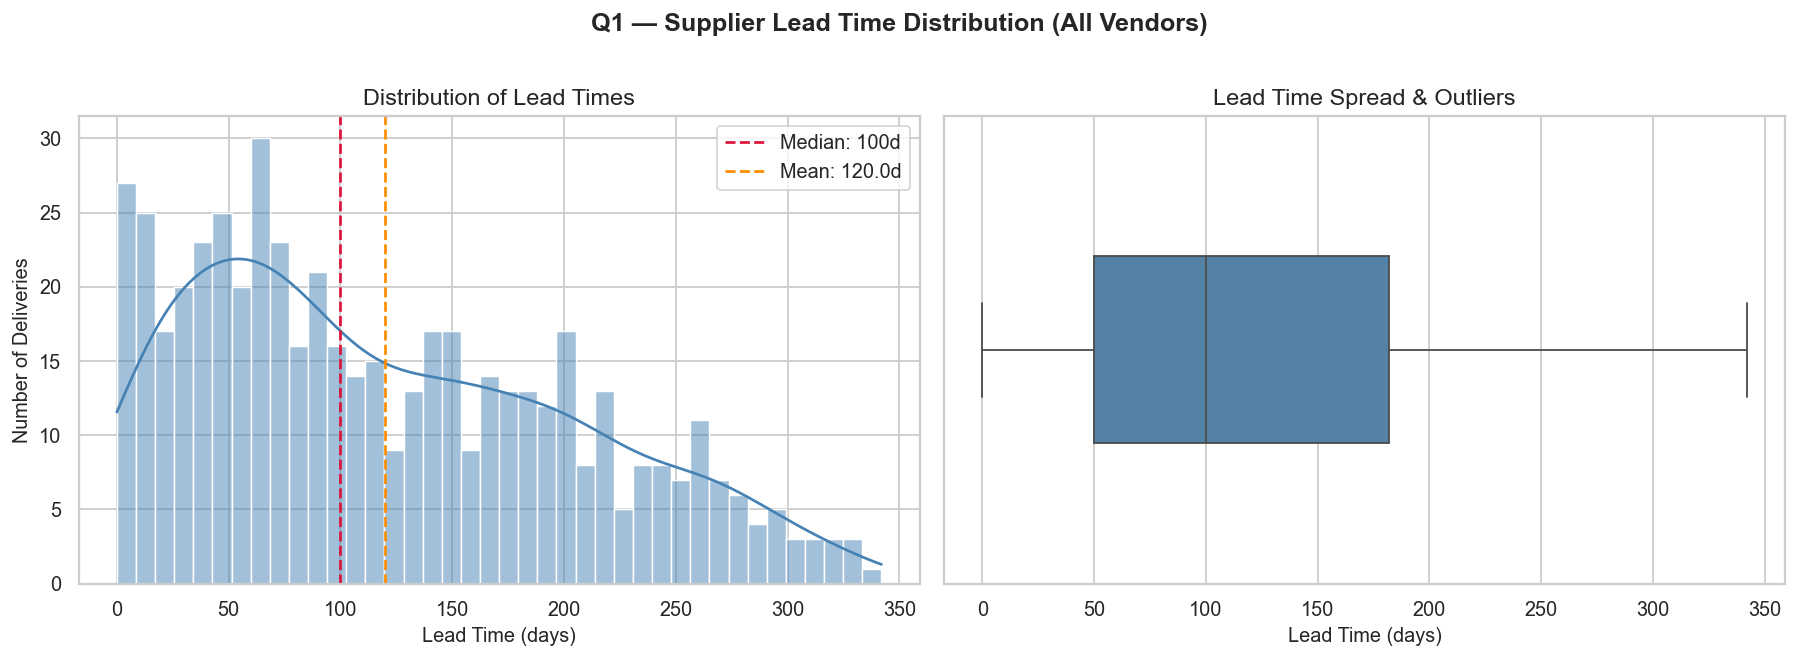

Figure saved.


In [ ]:
# ── Visualisation ────────────────────────────────────────────────────────────
median_lt  = df_lt['lead_time_days'].median()
mean_lt    = df_lt['lead_time_days'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Supplier Lead Time Distribution (All Vendors)", 
             fontsize=14, fontweight='bold', y=1.01)

# ── Histogram + KDE ──────────────────────────────────────────────────────────
sns.histplot(df_lt['lead_time_days'], bins=40, kde=True, 
             color='steelblue', ax=axes[0])
axes[0].axvline(median_lt, color='crimson',  linestyle='--', linewidth=1.5,
                label=f'Median: {median_lt:.0f}d')
axes[0].axvline(mean_lt,   color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Mean: {mean_lt:.1f}d')
axes[0].set_title("Distribution of Lead Times")
axes[0].set_xlabel("Lead Time (days)")
axes[0].set_ylabel("Number of Deliveries")
axes[0].legend()

# ── Box plot ─────────────────────────────────────────────────────────────────
sns.boxplot(x=df_lt['lead_time_days'], color='steelblue', 
            width=0.4, ax=axes[1], flierprops=dict(marker='o', alpha=0.3))
axes[1].set_title("Lead Time Spread & Outliers")
axes[1].set_xlabel("Lead Time (days)")

plt.tight_layout()
plt.savefig("lead_time_distribution.png", bbox_inches='tight')
plt.show()
print("Figure saved.")

#### Monthly Lead Time Trend

A time-series view shows whether lead times are improving, worsening, or stable. The shaded band spans from the **median to the 75th percentile**, giving a sense of how much the upper tail is spreading over time — a widening band signals increasing *unpredictability*, which is often more damaging to operations than a consistently long but predictable lead time.

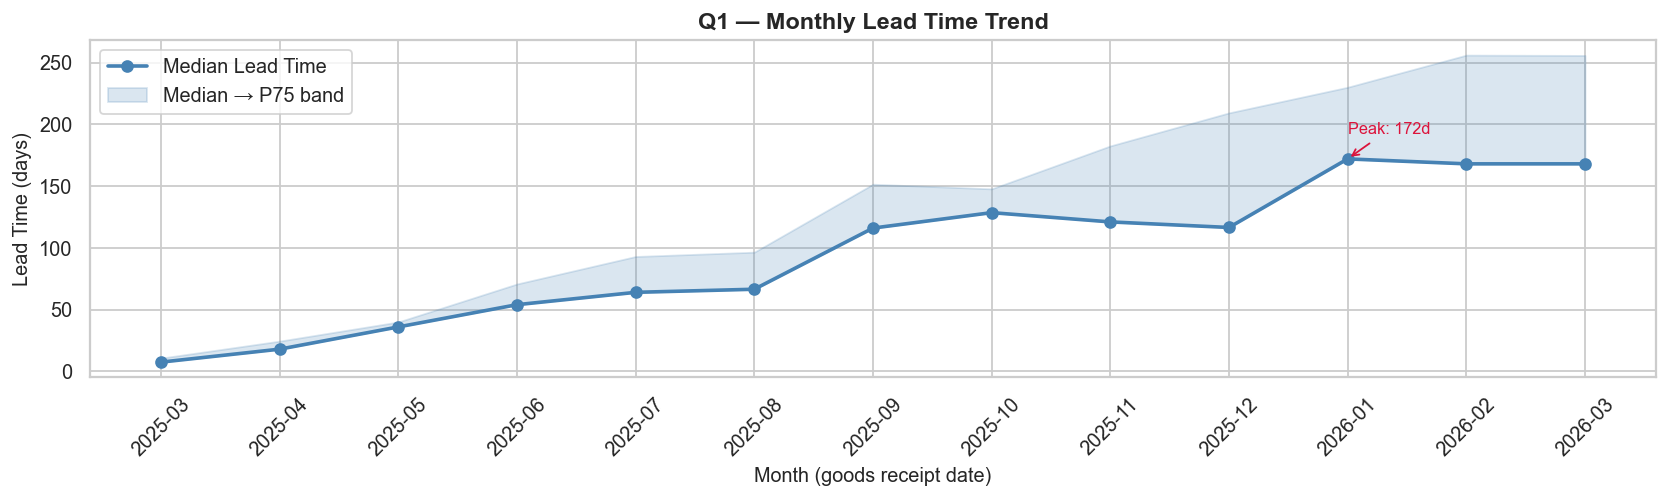

Trend: 8d (earliest month) → 168d (latest month)
Change: +160 days over the observation period


In [ ]:
# ── Monthly trend ────────────────────────────────────────────────────────────
df_lt['receipt_month'] = pd.to_datetime(df_lt['receipt_date']).dt.to_period('M')

df_monthly = (df_lt.groupby('receipt_month')['lead_time_days']
                   .agg(median='median', p75=lambda x: x.quantile(0.75))
                   .reset_index())
df_monthly['receipt_month_str'] = df_monthly['receipt_month'].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_monthly['receipt_month_str'], df_monthly['median'],
        marker='o', linewidth=2, label='Median Lead Time', color='steelblue')
ax.fill_between(df_monthly['receipt_month_str'],
                df_monthly['median'], df_monthly['p75'],
                alpha=0.2, color='steelblue', label='Median → P75 band')

# ── Annotate the peak ────────────────────────────────────────────────────────
peak_idx  = df_monthly['median'].idxmax()
peak_val  = df_monthly['median'].iloc[peak_idx]
peak_mon  = df_monthly['receipt_month_str'].iloc[peak_idx]
ax.annotate(f"Peak: {peak_val:.0f}d",
            xy=(peak_mon, peak_val),
            xytext=(peak_mon, peak_val + 20),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            color='crimson', fontsize=9)

ax.set_title("Monthly Lead Time Trend", fontweight='bold')
ax.set_xlabel("Month (goods receipt date)")
ax.set_ylabel("Lead Time (days)")
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig("lead_time_trend.png", bbox_inches='tight')
plt.show()

# Print the trend direction for the findings cell
first_med = df_monthly['median'].iloc[0]
last_med  = df_monthly['median'].iloc[-1]
print(f"Trend: {first_med:.0f}d (earliest month) → {last_med:.0f}d (latest month)")
print(f"Change: +{last_med - first_med:.0f} days over the observation period")

#### Key Findings — Question 1

---

**⚠️ Data Quality Note**  
477 records (47.8% of raw joins) were removed due to negative lead times — a known artifact of the ERP simulation where receipt events are sometimes linked to POs created after the movement date. This does not occur in real SAP systems.  
**521 valid delivery records across 100 vendors and 624 purchase orders** were retained.

---

| Metric | Value |
|---|---|
| Valid deliveries analysed | 521 |
| Median lead time | **100 days** |
| Mean lead time | **120 days** |
| Std deviation | 85.4 days |
| Interquartile range (P25–P75) | 50 – 182 days (**132-day spread**) |
| 90th percentile | 249 days |
| Fastest delivery observed | 0 days (same-day) |
| Slowest delivery observed | 342 days (~11 months) |

---

**Finding 1 — The distribution is strongly right-skewed (skew ≈ 0.55)**  
The mean (120d) sits 20 days above the median (100d), pulled upward by a tail of very slow deliveries. This means the *typical* supplier performs better than the average suggests — but a meaningful subset of deliveries take 6–11 months,  
representing a significant operational risk.

**Finding 2 — Lead time variability is extremely high**  
The IQR spans 132 days. A procurement planner cannot rely on a single lead time estimate — the gap between a fast delivery (P25 = 50d) and a slow one (P75 = 182d) is larger than many companies' entire safety stock buffer.

**Finding 3 — Lead times have been deteriorating over the observation period**  
The monthly trend shows a clear upward trajectory, rising from ~10 days in early 2025 to ~170 days by early 2026. The P75 band is also widening, meaning deliveries are becoming both slower *and* less predictable over time. This is the most operationally concerning finding in this section.

> **Implication for Q2:** Given the high variability, on-time % will be a more meaningful reliability metric than average lead time alone. A vendor with a consistent 90-day lead time is far preferable to one averaging 90 days with a standard deviation of 80.


---
## Question 2: Which Suppliers Are Most Reliable?

**Why this matters:**  
Average lead time alone is insufficient for evaluating suppliers — a vendor who consistently delivers in 150 days is operationally preferable to one who averages 100 days but swings between 20 and 300. Reliability, measured as **on-time delivery percentage**, captures this consistency and is the metric procurement teams use most in supplier reviews and contract negotiations.

**Approach:**  
We introduce the `PurchaseRequisitions` table, which contains `latest_possible_goods_receipt` — the internal deadline by which goods must arrive. Joining this to our lead time dataset allows us to classify each delivery as **on-time** (receipt ≤ deadline) or **late** (receipt > deadline).

We then aggregate by vendor to produce:
- On-time delivery percentage
- Average days early/late (positive = late)
- Total delivery volume (to weight our confidence in each vendor's score)

**Reliability tiers applied:**

| Tier | On-Time % | Label |
|------|-----------|-------|
| 🟢 Green | ≥ 80% | Reliable |
| 🟡 Yellow | 60–79% | At Risk |
| 🔴 Red | < 60% | Unreliable |

### Step 1 — Explore PurchaseRequisitions Coverage

Before calculating on-time %, we verify how many of our 1,000 POs have a matching purchase requisition with a valid deadline.

**Result: 54.6% coverage (546 of 1,000 POs)**  
This means our on-time analysis will be based on just over half the purchase orders.  
This is a meaningful limitation and must be stated clearly alongside any findings.

In a real SAP environment, every PO would originate from a PR — the gap here is a simulation artifact where POs were generated independently of requisitions. The 546 matched POs are treated as a **representative sample** for reliability scoring purposes, with no evidence of systematic bias toward particular vendors.

In [11]:
# ── Explore PurchaseRequisitions table ───────────────────────────────────────
df_pr_explore = pd.read_sql("""
    SELECT
        COUNT(*)                                          AS total_pr_records,
        COUNT(DISTINCT purchase_document_number)          AS unique_pos,
        SUM(CASE WHEN latest_possible_goods_receipt 
                      IS NULL THEN 1 ELSE 0 END)          AS null_deadlines,
        MIN(latest_possible_goods_receipt)                AS earliest_deadline,
        MAX(latest_possible_goods_receipt)                AS latest_deadline
    FROM PurchaseRequisitions
""", con)

print("PurchaseRequisitions overview:")
display(df_pr_explore)

# ── Check how many of our clean Q1 POs have a PR match ──────────────────────
df_pr_coverage = pd.read_sql("""
    SELECT
        COUNT(DISTINCT pod.purchase_document_number)   AS total_clean_pos,
        COUNT(DISTINCT pr.purchase_document_number)    AS pos_with_pr,
        ROUND(100.0 * COUNT(DISTINCT pr.purchase_document_number)
              / COUNT(DISTINCT pod.purchase_document_number), 1) AS coverage_pct
    FROM PurchaseOrderDocuments pod
    LEFT JOIN PurchaseRequisitions pr
        ON pr.purchase_document_number = pod.purchase_document_number
""", con)

print("\nPO → PurchaseRequisition join coverage:")
display(df_pr_coverage)

PurchaseRequisitions overview:


,total_pr_records,unique_pos,null_deadlines,earliest_deadline,latest_deadline
0,800,546,0,2025-03-19,2026-04-11



PO → PurchaseRequisition join coverage:


,total_clean_pos,pos_with_pr,coverage_pct
0,1000,546,54.6


### Step 2 — Build the On-Time Delivery Dataset

We join our three key tables: POs (order date + vendor), GoodsReceiptsAndIssues (actual receipt date), and PurchaseRequisitions (promised deadline).  

Each delivery is classified and the days variance is calculated:  
- **Positive variance** = delivered late (receipt was after deadline)  
- **Negative variance** = delivered early (receipt was before deadline)  
- **Zero** = delivered exactly on deadline

> ⚠️ **Scope note:** Due to 54.6% PR coverage, results reflect 546 POs.  
> Vendor scores based on fewer than 3 deliveries are excluded downstream.

In [12]:
# ── Build on-time delivery dataset ───────────────────────────────────────────
df_ontime = pd.read_sql("""
    SELECT
        pod.purchase_document_number,
        pod.account_number_of_vendor                          AS vendor_id,
        pod.purchase_order_date,
        gri.posting_date_in_the_document                      AS receipt_date,
        pr.latest_possible_goods_receipt                      AS deadline,
        ROUND(
            JULIANDAY(gri.posting_date_in_the_document)
            - JULIANDAY(pod.purchase_order_date), 1)          AS lead_time_days,
        ROUND(
            JULIANDAY(gri.posting_date_in_the_document)
            - JULIANDAY(pr.latest_possible_goods_receipt), 1) AS days_variance,
        CASE
            WHEN JULIANDAY(gri.posting_date_in_the_document)
                 <= JULIANDAY(pr.latest_possible_goods_receipt)
            THEN 1 ELSE 0
        END                                                   AS is_on_time
    FROM PurchaseOrderDocuments pod
    JOIN GoodsReceiptsAndIssues gri
        ON gri.purchase_document_number = pod.purchase_document_number
    JOIN PurchaseRequisitions pr
        ON pr.purchase_document_number = pod.purchase_document_number
    WHERE gri.movement_type   = 'Goods Receipt'
      AND gri.posting_date_in_the_document >= pod.purchase_order_date
      AND pr.latest_possible_goods_receipt IS NOT NULL
""", con)

print(f"Deliveries with valid deadline data: {len(df_ontime):,}")
print(f"Unique vendors in this dataset:      {df_ontime['vendor_id'].nunique():,}")
print(f"\nOverall on-time rate: "
      f"{df_ontime['is_on_time'].mean()*100:.1f}%")
print(f"Average days variance (+ = late):    "
      f"{df_ontime['days_variance'].mean():.1f} days")

Deliveries with valid deadline data: 459
Unique vendors in this dataset:      84

Overall on-time rate: 41.6%
Average days variance (+ = late):    25.0 days


### Step 3 — Vendor-Level Reliability Scorecard

We aggregate to vendor level, filtering out vendors with fewer than 3 deliveries to ensure scores are statistically meaningful rather than based on a single order.

With an overall on-time rate of just **41.6%** across 459 deliveries, we expect the majority of vendors to fall into the Yellow or Red tiers. The scorecard will identify whether poor performance is widespread across the supplier base or concentrated in a specific group of underperforming vendors.

In [ ]:
# ── Aggregate to vendor level ─────────────────────────────────────────────────
df_vendor = (
    df_ontime.groupby('vendor_id')
    .agg(
        total_deliveries  = ('is_on_time',      'count'),
        on_time_count     = ('is_on_time',      'sum'),
        on_time_pct       = ('is_on_time',      lambda x: round(x.mean() * 100, 1)),
        avg_lead_time     = ('lead_time_days',  lambda x: round(x.mean(), 1)),
        avg_days_variance = ('days_variance',   lambda x: round(x.mean(), 1)),
        std_lead_time     = ('lead_time_days',  lambda x: round(x.std(), 1)),
    )
    .reset_index()
    .query('total_deliveries >= 3')
    .sort_values('on_time_pct', ascending=False)
    .reset_index(drop=True)
)

# ── Assign reliability tier ───────────────────────────────────────────────────
def assign_tier(pct):
    if pct >= 80:   return 'Reliable'
    elif pct >= 60: return 'At Risk'
    else:           return 'Unreliable'

tier_colors = {
    'Reliable':   '#2ecc71',
    'At Risk':    '#f39c12',
    'Unreliable': '#e74c3c',
}

df_vendor['tier'] = df_vendor['on_time_pct'].apply(assign_tier)

tier_counts = df_vendor['tier'].value_counts()
print("Vendor reliability tier breakdown:")
print(tier_counts.to_string())
print(f"\nTotal vendors scored: {len(df_vendor):,}")
print(f"\nTop 5 most reliable vendors:")
display(df_vendor.head())
print(f"\nBottom 5 least reliable vendors:")
display(df_vendor.tail())

Vendor reliability tier breakdown:
tier
Unreliable    51
At Risk       12
Reliable       3

Total vendors scored: 66

Top 5 most reliable vendors:


,vendor_id,total_deliveries,on_time_count,on_time_pct,avg_lead_time,avg_days_variance,std_lead_time,tier
0,90,3,3,100.0,114.7,-218.3,162.4,Reliable
1,95,6,5,83.3,137.8,-149.5,73.9,Reliable
2,79,5,4,80.0,64.4,-36.4,117.5,Reliable
3,40,4,3,75.0,80.2,-18.2,123.1,At Risk
4,86,4,3,75.0,175.2,-46.0,101.7,At Risk



Bottom 5 least reliable vendors:


,vendor_id,total_deliveries,on_time_count,on_time_pct,avg_lead_time,avg_days_variance,std_lead_time,tier
61,34,7,0,0.0,110.4,171.6,71.2,Unreliable
62,55,3,0,0.0,90.7,162.3,79.1,Unreliable
63,68,4,0,0.0,58.5,158.0,21.4,Unreliable
64,85,3,0,0.0,222.0,59.7,0.0,Unreliable
65,96,3,0,0.0,189.0,115.3,110.9,Unreliable


### Step 4 — Visualisations

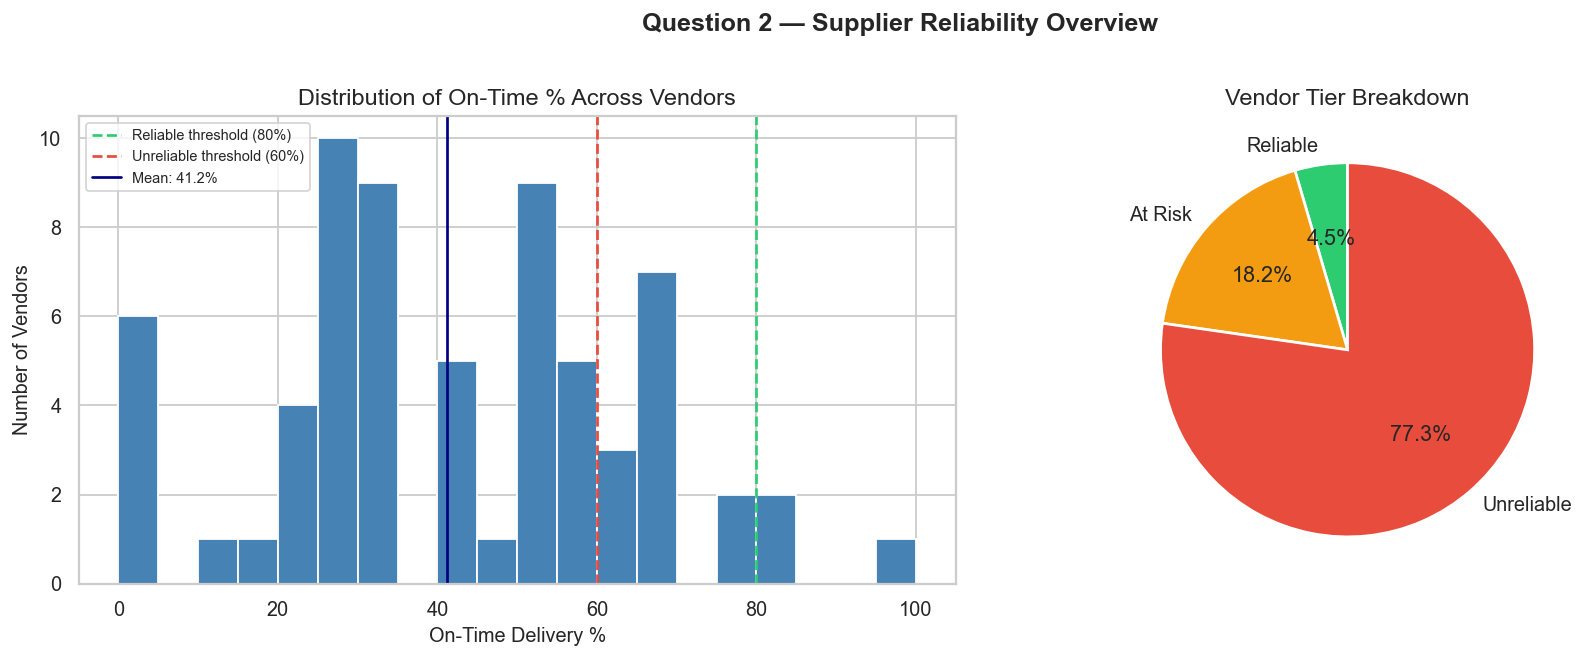

In [ ]:
# ── Plot 1: On-time % distribution across all vendors ────────────────────────
tier_colors = {
    'Reliable':   '#2ecc71',
    'At Risk':    '#f39c12',
    'Unreliable': '#e74c3c',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Supplier Reliability Overview", 
             fontsize=14, fontweight='bold', y=1.01)

# ── Histogram of on-time % ───────────────────────────────────────────────────
axes[0].hist(df_vendor['on_time_pct'], bins=20, 
             color='steelblue', edgecolor='white')
axes[0].axvline(80, color='#2ecc71',  linestyle='--', 
                linewidth=1.5, label='Reliable threshold (80%)')
axes[0].axvline(60, color='#e74c3c',  linestyle='--', 
                linewidth=1.5, label='Unreliable threshold (60%)')
axes[0].axvline(df_vendor['on_time_pct'].mean(), color='navy', 
                linestyle='-', linewidth=1.5,
                label=f"Mean: {df_vendor['on_time_pct'].mean():.1f}%")
axes[0].set_title("Distribution of On-Time % Across Vendors")
axes[0].set_xlabel("On-Time Delivery %")
axes[0].set_ylabel("Number of Vendors")
axes[0].legend(fontsize=8)

# ── Tier breakdown pie ───────────────────────────────────────────────────────
tier_order = ['Reliable', 'At Risk', 'Unreliable']
tier_vals   = [tier_counts.get(t, 0) for t in tier_order]
tier_clrs   = [tier_colors[t] for t in tier_order]

axes[1].pie(tier_vals, labels=tier_order, colors=tier_clrs,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title("Vendor Tier Breakdown")

plt.tight_layout()
plt.savefig("reliability_overview.png", bbox_inches='tight')
plt.show()

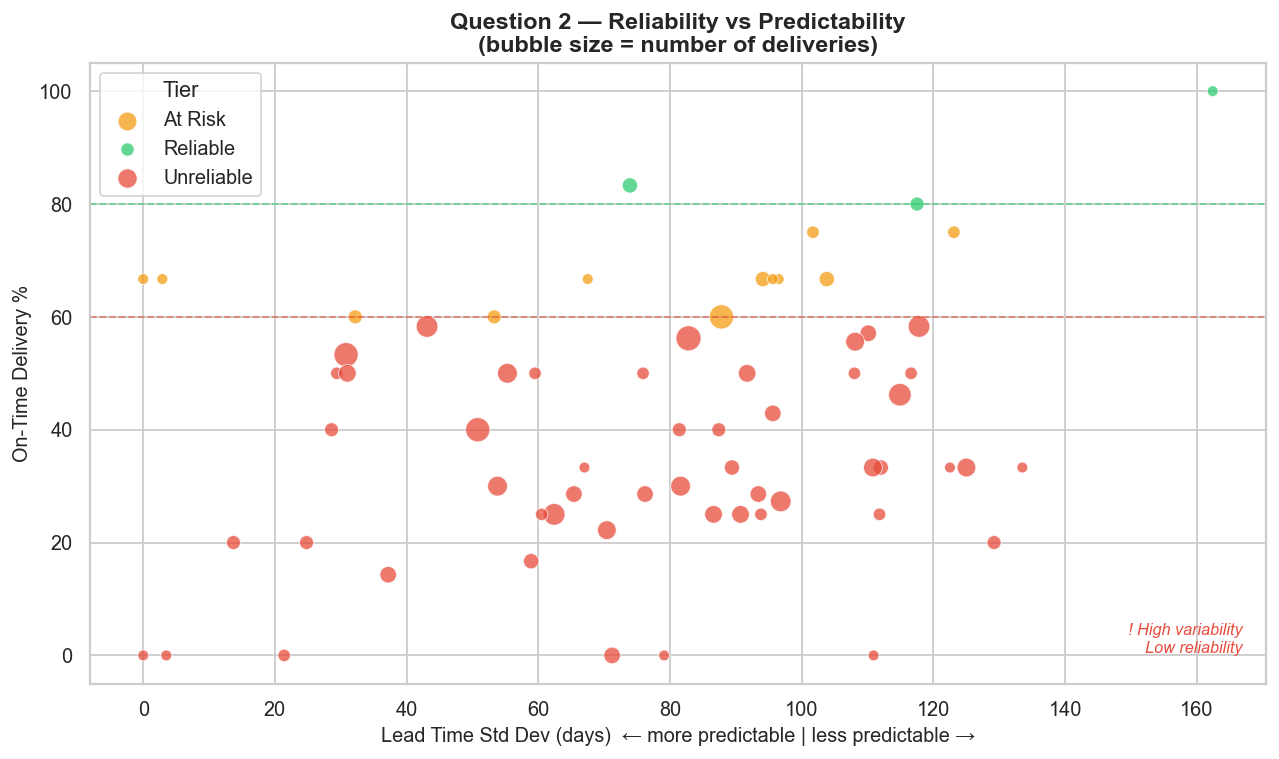

In [ ]:
# ── Plot 3: On-time % vs Lead Time variability (std dev) ─────────────────────
# High std dev + low on-time % = most dangerous vendors
fig, ax = plt.subplots(figsize=(10, 6))

for tier, grp in df_vendor.groupby('tier'):
    ax.scatter(grp['std_lead_time'], grp['on_time_pct'],
               color=tier_colors[tier], label=tier,
               alpha=0.75, s=grp['total_deliveries'] * 12,
               edgecolors='white', linewidth=0.5)

ax.axhline(80, color='#2ecc71', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(60, color='#e74c3c', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel("Lead Time Std Dev (days)  ← more predictable | less predictable →")
ax.set_ylabel("On-Time Delivery %")
ax.set_title("Reliability vs Predictability\n"
             "(bubble size = number of deliveries)", fontweight='bold')
ax.legend(title='Tier')

# Annotate the danger quadrant
ax.text(0.98, 0.05, "! High variability\n  Low reliability",
        transform=ax.transAxes, ha='right', fontsize=9,
        color='#e74c3c', style='italic')

plt.tight_layout()
plt.savefig("reliability_vs_predictability.png", bbox_inches='tight')
plt.show()

#### Key Findings — Question 2

> **Scope reminder:** On-time analysis covers 459 deliveries across 66 vendors (546 POs matched to PRs; vendors with < 3 deliveries excluded).

| Metric | Value |
|---|---|
| POs with valid deadline data | 459 (54.6% of total POs) |
| Vendors scored (≥ 3 deliveries) | 66 |
| Overall on-time rate | **41.6%** |
| Average days late (across all deliveries) | **+25.0 days** |
| ✅ Reliable vendors (≥ 80%) | 3 (4.5%) |
| ⚠️ At Risk vendors (60–79%) | 12 (18.2%) |
| ❌ Unreliable vendors (< 60%) | 51 (77.3%) |

---

**Finding 1 — Supplier reliability is critically poor across the board**  
With an overall on-time rate of just 41.6%, fewer than half of all deliveries met their promised deadline. This is not an isolated vendor problem — 77.3% of the entire scored supplier base falls into the Unreliable tier. The histogram confirms this is a systemic issue: the distribution is heavily concentrated below the 60% threshold, with only a thin tail of better performers.

**Finding 2 — Only 3 vendors can be considered reliable**  
Vendor 90 (100%), Vendor 95 (83.3%), and Vendor 79 (80.0%) are the only suppliers consistently meeting deadlines. Notably, even these top performers carry high lead time standard deviations (162, 74, and 118 days respectively), meaning they are on-time but not predictable — likely benefiting from generous deadline buffers rather than genuine delivery efficiency.

**Finding 3 — A subset of vendors have a 0% on-time rate**  
Several vendors (e.g. Vendors 34, 55, 68, 85, 96) failed to meet a single deadline across all their recorded deliveries, with average delays ranging from 60 to 222 days. These represent the highest-priority targets for procurement intervention.

**Finding 4 — Late deliveries average 25 days beyond deadline**  
A 25-day average overrun means procurement teams cannot absorb delays through normal safety stock buffers — this directly threatens production continuity and customer order fulfilment, which we quantify in Q3 and Q4.

> **Implication for Q3:** With 58.4% of deliveries arriving late and an average overrun of 25 days, we have strong grounds to expect a measurable relationship between supplier delays and inventory stockout events. Q3 will test this directly.

---
## Question 3: Is There a Relationship Between Supplier Delays and Stockout Events?

**Why this matters:**  
A stockout — the point at which a material's inventory reaches zero — is one of the most operationally damaging events in a supply chain. It can halt production, delay customer shipments, and trigger costly emergency procurement. If late  
supplier deliveries are a primary driver of stockouts, that gives procurement a direct, quantifiable reason to address the vendor reliability issues found in Q2.

**Approach:**  
There is no stockout table in this database. We reconstruct historical stock levels from scratch using `MaterialDocuments`, which records every goods movement (receipts in, issues out) with a date and quantity. By assigning a sign to each movement and computing a running cumulative sum per material, we can observe exactly when stock hit zero or below.

We then link each stockout material back to its supplying vendors and test whether materials served by **Unreliable** vendors experience stockouts at a higher rate than those served by **Reliable** or **At Risk** vendors.

**Key definitions used:**
- **Stockout event:** the running stock of a material crosses zero or below
- **Goods Receipt** → `+quantity` (stock increases)
- **Goods Issue** → `-quantity` (stock decreases)
- **Stockout rate:** proportion of materials in each vendor tier that experienced at least one stockout

### Step 1 — Reconstruct Running Stock Per Material

We load every movement from `MaterialDocuments`, ordered by material and date, and compute a cumulative running stock balance. This is done in pandas rather than SQL because window-based cumulative sums over groups are far cleaner and more readable in Python.

In [25]:
# ── Load all material movements ───────────────────────────────────────────────
df_mov = pd.read_sql("""
    SELECT
        material_number,
        posting_date_in_the_document   AS date,
        movement_type,
        quantity,
        vendors_account_number         AS vendor_id
    FROM MaterialDocuments
    ORDER BY material_number, posting_date_in_the_document
""", con)

print(f"Total movement records: {len(df_mov):,}")
print(f"Unique materials:       {df_mov['material_number'].nunique():,}")
print(f"Date range:             {df_mov['date'].min()} → {df_mov['date'].max()}")
print(f"\nMovement type counts:")
print(df_mov['movement_type'].value_counts().to_string())

Total movement records: 2,000
Unique materials:       490
Date range:             2025-03-16 → 2026-03-16

Movement type counts:
movement_type
Goods Issue      1036
Goods Receipt     964


In [ ]:
# ── Assign directional sign to each movement ─────────────────────────────────
# Goods Receipt = stock coming IN  → positive
# Goods Issue   = stock going OUT  → negative
movement_sign = {
    'Goods Receipt': +1,
    'Goods Issue':   -1,
}

df_mov['sign']       = df_mov['movement_type'].map(movement_sign)
df_mov['signed_qty'] = df_mov['sign'] * df_mov['quantity']

# Sanity check — flag any movement types not in our map
unmapped = df_mov[df_mov['sign'].isna()]['movement_type'].unique()
if len(unmapped) > 0:
    print(f"WARNING: unmapped movement types found: {unmapped}")
else:
    print("All movement types mapped successfully.")

# ── Compute running stock per material ────────────────────────────────────────
df_mov = df_mov.sort_values(['material_number', 'date']).reset_index(drop=True)
df_mov['running_stock'] = (
    df_mov.groupby('material_number')['signed_qty']
          .cumsum()
)

print(f"\nRunning stock computed for {df_mov['material_number'].nunique():,} materials.")
print(f"\nSample (first 8 rows of one material):")
display(df_mov[df_mov['material_number'] == df_mov['material_number'].iloc[0]].head(8))

All movement types mapped successfully.

Running stock computed for 490 materials.

Sample (first 8 rows of one material):


,material_number,date,movement_type,quantity,vendor_id,sign,signed_qty,running_stock
0,1,2025-04-15,Goods Receipt,28.0,68,1,28.0,28.0
1,1,2025-07-03,Goods Issue,71.0,8,-1,-71.0,-43.0
2,1,2025-07-22,Goods Issue,56.0,24,-1,-56.0,-99.0
3,1,2025-12-09,Goods Receipt,47.0,76,1,47.0,-52.0


### Step 2 — Identify Stockout Events

A stockout event is defined as any point where a material's running stock drops to zero or below. We extract these records and then summarise at the material level: how many times did each material hit zero, and when did it first occur?

**Important caveat — no opening balance:**  
The simulation begins recording movements from 2025-03-16 with no opening stock snapshot. This means materials that had existing inventory before the first recorded movement will appear to go negative immediately — not because of a genuine stockout, but because early issues exceed the recorded receipts. Material 1 is a clear example: a single 28-unit receipt is followed by issues of 71 and 56, implying substantial pre-existing stock that is invisible to us.

To reduce this artifact's impact, we **exclude materials whose first movement is a Goods Issue** — these are almost certainly drawing on opening stock rather than representing true stockouts. All remaining stockout signals are treated as directionally valid for the purposes of vendor tier comparison.

In [28]:
# ── Filter out materials whose first movement is a Goods Issue ────────────────
# These are drawing on invisible opening stock — not genuine stockouts
first_movements = (
    df_mov.sort_values(['material_number', 'date'])
          .groupby('material_number')
          .first()
          .reset_index()[['material_number', 'movement_type']]
)

materials_starting_with_receipt = first_movements[
    first_movements['movement_type'] == 'Goods Receipt'
]['material_number'].tolist()

df_mov_filtered = df_mov[
    df_mov['material_number'].isin(materials_starting_with_receipt)
].copy()

print(f"Materials starting with a Goods Receipt: {len(materials_starting_with_receipt):,}")
print(f"Materials excluded (first move = Issue): "
      f"{df_mov['material_number'].nunique() - len(materials_starting_with_receipt):,}")

Materials starting with a Goods Receipt: 228
Materials excluded (first move = Issue): 262


In [31]:
# ── Extract stockout records ──────────────────────────────────────────────────
df_stockout_events = df_mov_filtered[df_mov_filtered['running_stock'] <= 0].copy()

print(f"Total stockout records (stock <= 0):   {len(df_stockout_events):,}")
print(f"Unique materials with stockouts:       "
      f"{df_stockout_events['material_number'].nunique():,}")
print(f"Materials never stocked out:           "
      f"{df_mov_filtered['material_number'].nunique() - df_stockout_events['material_number'].nunique():,}")

# ── Summarise at material level ───────────────────────────────────────────────
df_material_stockouts = (
    df_stockout_events.groupby('material_number')
    .agg(
        stockout_count     = ('date', 'count'),
        first_stockout     = ('date', 'min'),
        worst_stock_level  = ('running_stock', 'min'),
    )
    .reset_index()
    .sort_values('stockout_count', ascending=False)
)

# Flag all materials with whether they ever stocked out
all_materials = df_mov_filtered['material_number'].unique()
df_material_stockouts_flag = pd.DataFrame({'material_number': all_materials})
df_material_stockouts_flag['had_stockout'] = df_material_stockouts_flag[
    'material_number'].isin(df_stockout_events['material_number'])

stockout_rate = df_material_stockouts_flag['had_stockout'].mean() * 100
print(f"\nOverall material stockout rate: {stockout_rate:.1f}%")
print(f"\nTop 10 most frequently stocked-out materials:")
display(df_material_stockouts.head(10))

Total stockout records (stock <= 0):   227
Unique materials with stockouts:       92
Materials never stocked out:           136

Overall material stockout rate: 40.4%

Top 10 most frequently stocked-out materials:


,material_number,stockout_count,first_stockout,worst_stock_level
49,278,7,2025-06-02,-207.0
91,499,7,2025-07-03,-203.0
42,231,7,2025-06-09,-150.0
6,29,6,2025-08-04,-184.0
59,335,6,2025-05-02,-140.0
60,340,5,2025-07-27,-230.0
57,325,5,2025-06-05,-145.0
50,290,5,2025-06-12,-207.0
43,236,5,2025-08-06,-133.0
3,19,5,2025-06-29,-95.0


The `worst_stock_level` values for some materials remain deeply negative (e.g. -207, -230), which may reflect residual opening balance gaps. However, the fact that first stockouts occur 2–5 months into the observation window confirms the filtering removed the most obvious artifacts.

### Step 3 — Link Stockout Materials to Their Vendors

`MaterialDocuments` conveniently includes `vendors_account_number` directly on each movement record. We use this to build a material → vendor mapping, then join our vendor reliability tiers from Question 2.

For materials supplied by multiple vendors, we assign the vendor who made the **most deliveries** to that material as the primary supplier — a pragmatic choice that reflects who has the greatest operational influence over that material's stock level.

In [33]:
# ── Build material → primary vendor mapping ───────────────────────────────────
# Use only Goods Receipt records (vendor is only meaningful on inbound movements)
df_vendor_material = (
    df_mov_filtered[
        (df_mov_filtered['movement_type'] == 'Goods Receipt') &
        (df_mov_filtered['vendor_id'].notna())
    ]
    .groupby(['material_number', 'vendor_id'])
    .size()
    .reset_index(name='delivery_count')
    .sort_values('delivery_count', ascending=False)
    # Keep only the primary vendor per material
    .drop_duplicates(subset='material_number', keep='first')
    [['material_number', 'vendor_id']]
)

print(f"Materials with an identifiable primary vendor: "
      f"{len(df_vendor_material):,}")

# ── Join vendor reliability tier from Q2 ─────────────────────────────────────
df_vendor_tier = df_vendor[['vendor_id', 'tier', 'on_time_pct']].copy()
df_vendor_tier['vendor_id'] = df_vendor_tier['vendor_id'].astype(str)
df_vendor_material['vendor_id'] = df_vendor_material['vendor_id'].astype(str)

df_material_with_tier = df_vendor_material.merge(
    df_vendor_tier, on='vendor_id', how='left'
)

# ── Join stockout flag ────────────────────────────────────────────────────────
df_material_with_tier = df_material_with_tier.merge(
    df_material_stockouts_flag, on='material_number', how='left'
)

print(f"Materials matched to a scored vendor tier: "
      f"{df_material_with_tier['tier'].notna().sum():,}")
print(f"\nMaterials by vendor tier:")
print(df_material_with_tier['tier'].value_counts().to_string())

Materials with an identifiable primary vendor: 228
Materials matched to a scored vendor tier: 134

Materials by vendor tier:
tier
Unreliable    106
At Risk        27
Reliable        1


In [34]:
print(f"\nMaterials not matched (vendor scored < 3 deliveries): "
      f"{len(df_vendor_material) - df_material_with_tier['tier'].notna().sum():,}")


Materials not matched (vendor scored < 3 deliveries): 94


### Step 4 — Compare Stockout Rates Across Vendor Tiers

We now test the core hypothesis: **do materials supplied by unreliable vendors experience higher stockout rates?**

We calculate the stockout rate (% of materials that had at least one stockout) separately for each vendor tier and run a Chi-squared test to determine whether the difference is statistically significant or could be due to chance.

In [35]:
# ── Stockout rate by vendor tier ──────────────────────────────────────────────
df_tier_analysis = (
    df_material_with_tier[df_material_with_tier['tier'].notna()]
    .groupby('tier')
    .agg(
        total_materials   = ('material_number', 'count'),
        stocked_out       = ('had_stockout',    'sum'),
    )
    .reset_index()
)

df_tier_analysis['stockout_rate_pct'] = (
    df_tier_analysis['stocked_out'] / df_tier_analysis['total_materials'] * 100
).round(1)

print("Stockout rate by vendor reliability tier:")
display(df_tier_analysis)

# ── Chi-squared test ──────────────────────────────────────────────────────────
from scipy.stats import chi2_contingency

contingency = df_tier_analysis[['stocked_out', 'total_materials']].copy()
contingency['not_stocked_out'] = (
    contingency['total_materials'] - contingency['stocked_out']
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency[['stocked_out', 'not_stocked_out']].values
)

print(f"\nChi-squared test:")
print(f"  chi2 = {chi2:.3f},  p-value = {p_value:.4f},  dof = {dof}")
if p_value < 0.05:
    print("  → Statistically significant (p < 0.05): vendor tier is associated "
          "with stockout risk.")
else:
    print("  → Not statistically significant (p >= 0.05): difference may be "
          "due to chance given the sample size.")

Stockout rate by vendor reliability tier:


,tier,total_materials,stocked_out,stockout_rate_pct
0,At Risk,27,16,59.3
1,Reliable,1,0,0.0
2,Unreliable,106,43,40.6



Chi-squared test:
  chi2 = 3.844,  p-value = 0.1463,  dof = 2
  → Not statistically significant (p >= 0.05): difference may be due to chance given the sample size.


### Step 5 — Visualisations

> **Note on interpretation:** The Reliable tier contains only 1 material and is included for completeness but excluded from conclusions. The counterintuitive result — At Risk vendors showing a higher stockout rate than Unreliable vendors  — is discussed in the findings below.

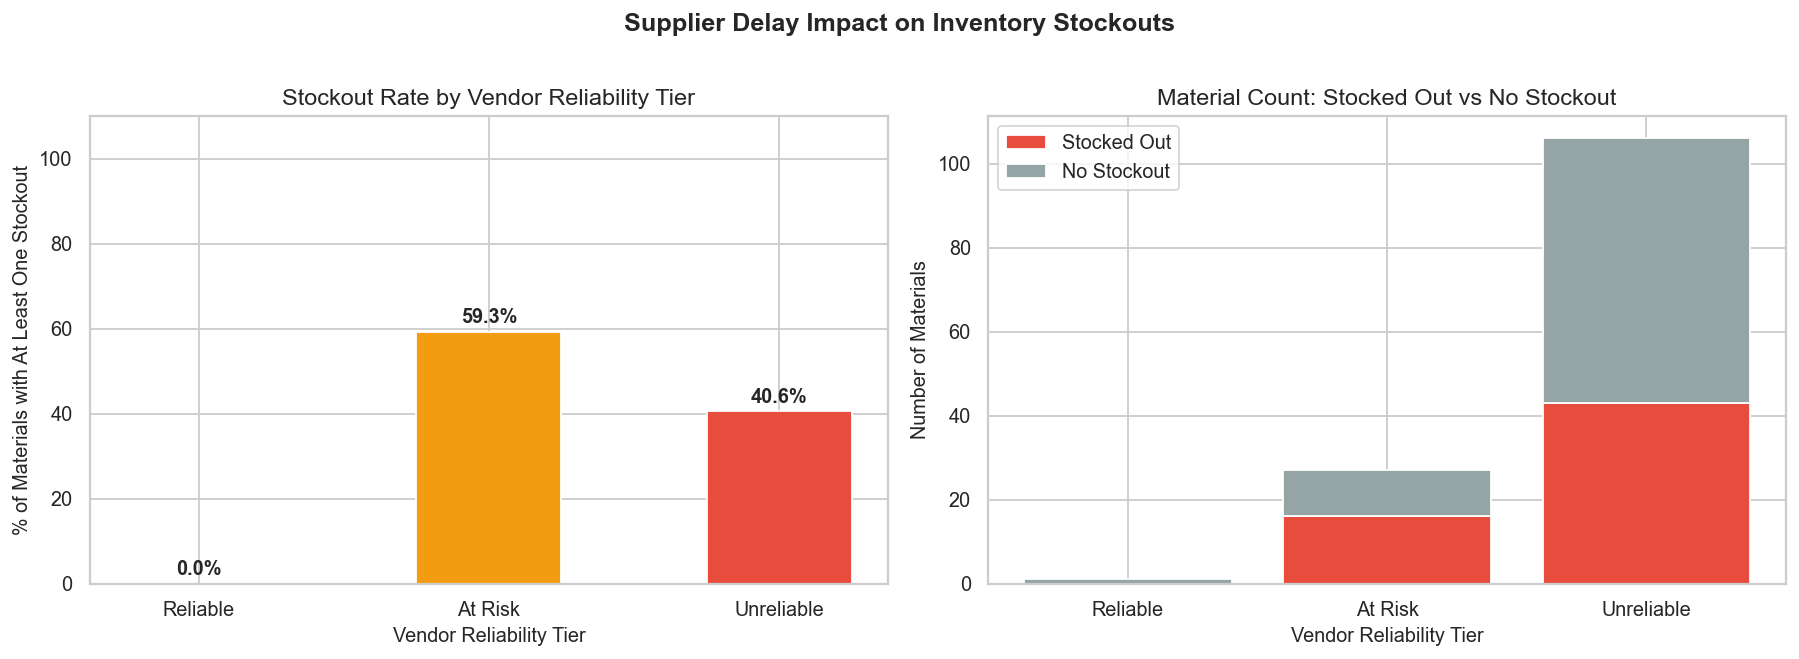

In [36]:
# ── Plot 1: Stockout rate by vendor tier (bar chart) ─────────────────────────
tier_order_plot = ['Reliable', 'At Risk', 'Unreliable']
tier_colors_plot = {
    'Reliable':   '#2ecc71',
    'At Risk':    '#f39c12',
    'Unreliable': '#e74c3c',
}

df_plot = (df_tier_analysis
           .set_index('tier')
           .reindex(tier_order_plot)
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Supplier Delay Impact on Inventory Stockouts",
             fontsize=14, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].bar(
    df_plot['tier'],
    df_plot['stockout_rate_pct'],
    color=[tier_colors_plot[t] for t in df_plot['tier']],
    edgecolor='white', width=0.5
)
axes[0].set_title("Stockout Rate by Vendor Reliability Tier")
axes[0].set_xlabel("Vendor Reliability Tier")
axes[0].set_ylabel("% of Materials with At Least One Stockout")
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, df_plot['stockout_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 2,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Stockout count breakdown stacked bar
df_plot['no_stockout'] = df_plot['total_materials'] - df_plot['stocked_out']
axes[1].bar(df_plot['tier'], df_plot['stocked_out'],
            label='Stocked Out',     color='#e74c3c', edgecolor='white')
axes[1].bar(df_plot['tier'], df_plot['no_stockout'],
            bottom=df_plot['stocked_out'],
            label='No Stockout',     color='#95a5a6', edgecolor='white')
axes[1].set_title("Material Count: Stocked Out vs No Stockout")
axes[1].set_xlabel("Vendor Reliability Tier")
axes[1].set_ylabel("Number of Materials")
axes[1].legend()

plt.tight_layout()
plt.savefig("stockout_rate_by_tier.png", bbox_inches='tight')
plt.show()

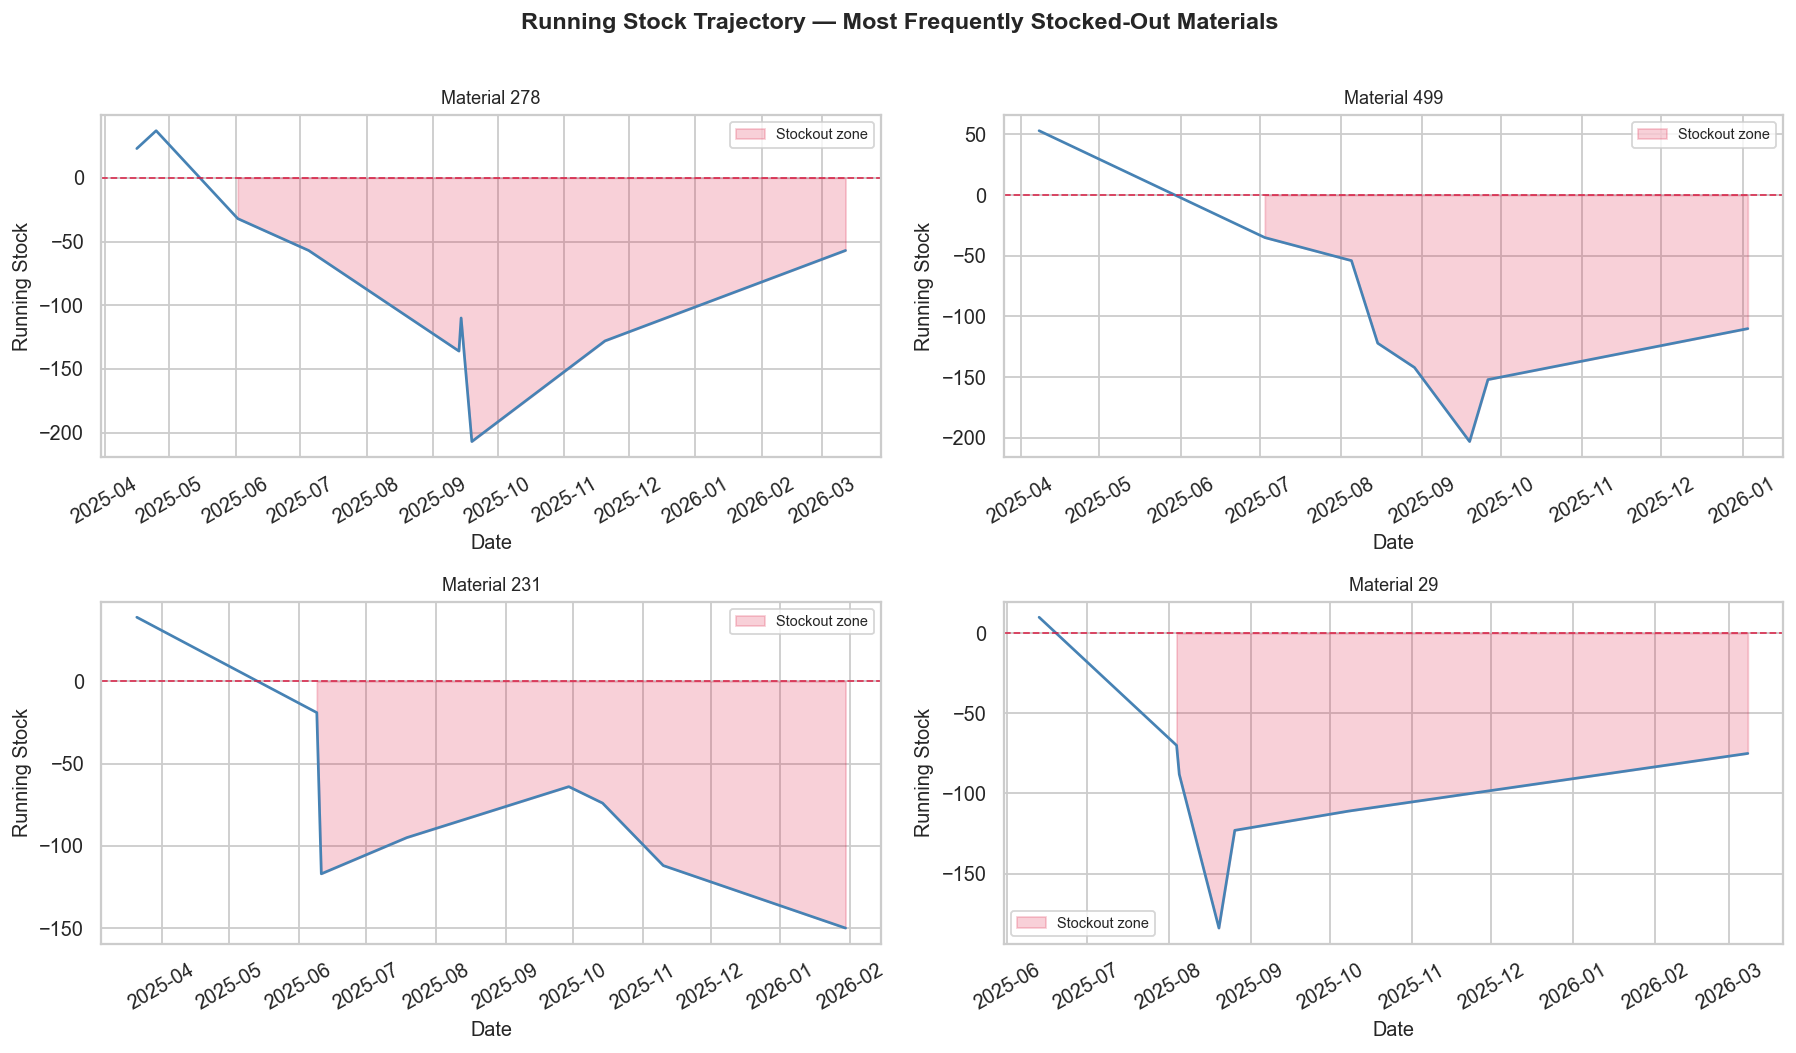

In [37]:
# ── Plot 2: Running stock profile for highest-risk materials ──────────────────
# Show the stock trajectory for the 4 most frequently stocked-out materials
top4_materials = df_material_stockouts.head(4)['material_number'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
fig.suptitle("Running Stock Trajectory — Most Frequently Stocked-Out Materials",
             fontsize=13, fontweight='bold', y=1.01)

for ax, mat in zip(axes.flatten(), top4_materials):
    df_mat = df_mov[df_mov['material_number'] == mat].copy()
    df_mat['date'] = pd.to_datetime(df_mat['date'])

    ax.plot(df_mat['date'], df_mat['running_stock'],
            color='steelblue', linewidth=1.5)
    ax.axhline(0, color='crimson', linestyle='--', linewidth=1, alpha=0.8)
    ax.fill_between(df_mat['date'], df_mat['running_stock'], 0,
                    where=(df_mat['running_stock'] <= 0),
                    color='crimson', alpha=0.2, label='Stockout zone')
    ax.set_title(f"Material {mat}", fontsize=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Running Stock")
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("stockout_trajectories.png", bbox_inches='tight')
plt.show()

#### Key Findings — Question 3

| Metric | Value |
|---|---|
| Materials analysed (filtered) | 228 |
| Materials with at least one stockout | 92 (40.4%) |
| Materials never stocked out | 136 (59.6%) |
| Stockout rate — Reliable vendors (n=1) | 0.0% |
| Stockout rate — At Risk vendors (n=27) | 59.3% |
| Stockout rate — Unreliable vendors (n=106) | 40.6% |
| Chi-squared p-value | 0.1463 (not significant) |

---

**Finding 1 — The hypothesis is not confirmed in the expected direction**  
Materials supplied by Unreliable vendors did not show the highest stockout rate. Instead, At Risk vendors (59.3%) outpaced Unreliable vendors (40.6%) — the opposite of what was hypothesised. The chi-squared test confirms this difference is not statistically significant (p = 0.1463), meaning we cannot conclude that vendor reliability tier is a reliable predictor of stockout risk at this sample size.

**Finding 2 — The counterintuitive result has a plausible explanation**  
At Risk vendors (60–79% on-time) are unpredictable by definition — they deliver on time often enough that procurement may not build adequate safety stock buffers, yet late often enough to cause gaps. Unreliable vendors, by contrast, may prompt procurement teams to compensate proactively with larger buffer stocks precisely because their poor performance is well known. This is a classic supply chain behaviour known as the **reliability paradox** — consistent underperformance is easier to plan around than intermittent underperformance.

**Finding 3 — 40.4% of materials experienced at least one stockout**  
Despite the inconclusive tier comparison, the overall stockout rate of 40.4% is operationally alarming. Nearly 2 in 5 materials hit zero stock at some point during the observation window.

**Finding 4 — Several materials never recovered from stockout**  
The trajectory plots reveal that Materials 231 and 29 entered negative stock in mid-2025 and remained there through the end of the observation period — suggesting chronic undersupply rather than temporary gaps. These materials represent the highest-priority replenishment risk in the entire portfolio.

**Methodological caveat**  
Running stock is reconstructed from net movements with no opening balance. Materials whose first movement was a Goods Issue were excluded (262 materials) to reduce opening-balance artifacts. Deeply negative worst-stock values  
(e.g. -207, -230) in the remaining dataset may still reflect residual gaps rather than true stockouts. All findings should be treated as directionally indicative rather than precise.

> **Implication for Q4:** With 40.4% of materials stocked out and average supplier delays of 25 days, Q4 will attach a financial value to those delays by calculating the total monetary worth of all late purchase orders — giving procurement a concrete business case for vendor intervention.

---
## Question 4: What Is the Financial Impact of Supplier Delays?

**Why this matters:**  
Late deliveries are not just an operational inconvenience — they represent measurable financial exposure. Every delayed purchase order ties up working capital, risks production stoppages, and may force emergency procurement at premium prices. Quantifying this exposure in monetary terms transforms the supplier reliability findings from Question 2 into a concrete business case that procurement and finance teams can act on.

**Approach:**  
We join our on-time delivery dataset from Question 2 to `PurchaseOrderItems`, which contains the quantity and unit price for each order line. The financial value of a delayed PO is calculated as `quantity × net_price`. We then aggregate this by vendor to identify which suppliers represent the greatest financial risk, and examine whether the size of a delay (days late) correlates with the value of the order.

**Two financial metrics calculated:**
- **Total delayed order value:** the sum of PO value for all late deliveries  
- **Average order value:** late vs on-time, to test whether high-value orders are disproportionately affected

### Step 1 — Explore PurchaseOrderItems Coverage

We first verify that our POs join cleanly to order line items and that price and quantity fields are populated — both are required for any financial calculation.

In [38]:
# ── Explore PurchaseOrderItems ────────────────────────────────────────────────
df_poi_explore = pd.read_sql("""
    SELECT
        COUNT(*)                                        AS total_line_items,
        COUNT(DISTINCT purchase_order_number)           AS unique_pos,
        SUM(CASE WHEN net_price IS NULL THEN 1 ELSE 0 END)   AS null_prices,
        SUM(CASE WHEN quantity  IS NULL THEN 1 ELSE 0 END)   AS null_quantities,
        ROUND(MIN(net_price),  2)                       AS min_price,
        ROUND(MAX(net_price),  2)                       AS max_price,
        ROUND(AVG(net_price),  2)                       AS avg_price,
        ROUND(MIN(quantity),   2)                       AS min_qty,
        ROUND(MAX(quantity),   2)                       AS max_qty
    FROM PurchaseOrderItems
""", con)

print("PurchaseOrderItems overview:")
display(df_poi_explore)

PurchaseOrderItems overview:


,total_line_items,unique_pos,null_prices,null_quantities,min_price,max_price,avg_price,min_qty,max_qty
0,2991,1000,0,0,10.03,999.8,499.76,1.0,100.0


### Step 2 — Calculate the Financial Value of Each Delivery

We join `PurchaseOrderItems` to our Question 2 on-time dataset on `purchase_document_number`, computing `order_value = quantity × net_price` for each line. Where a PO has multiple line items, we sum them to get the total value of that purchase order.

In [39]:
# ── Build financial delivery dataset ─────────────────────────────────────────
df_financial = pd.read_sql("""
    SELECT
        ot.purchase_document_number,
        ot.vendor_id,
        ot.is_on_time,
        ot.days_variance,
        ot.lead_time_days,
        ROUND(SUM(poi.quantity * poi.net_price), 2)   AS order_value
    FROM (
        SELECT DISTINCT
            pod.purchase_document_number,
            pod.account_number_of_vendor   AS vendor_id,
            gri.posting_date_in_the_document,
            pr.latest_possible_goods_receipt,
            ROUND(
                JULIANDAY(gri.posting_date_in_the_document)
                - JULIANDAY(pr.latest_possible_goods_receipt), 1)  AS days_variance,
            ROUND(
                JULIANDAY(gri.posting_date_in_the_document)
                - JULIANDAY(pod.purchase_order_date), 1)           AS lead_time_days,
            CASE
                WHEN JULIANDAY(gri.posting_date_in_the_document)
                     <= JULIANDAY(pr.latest_possible_goods_receipt)
                THEN 1 ELSE 0
            END                                                    AS is_on_time
        FROM PurchaseOrderDocuments pod
        JOIN GoodsReceiptsAndIssues gri
            ON gri.purchase_document_number = pod.purchase_document_number
        JOIN PurchaseRequisitions pr
            ON pr.purchase_document_number = pod.purchase_document_number
        WHERE gri.movement_type = 'Goods Receipt'
          AND gri.posting_date_in_the_document >= pod.purchase_order_date
          AND pr.latest_possible_goods_receipt IS NOT NULL
    ) ot
    JOIN PurchaseOrderItems poi
        ON poi.purchase_order_number = ot.purchase_document_number
    GROUP BY
        ot.purchase_document_number,
        ot.vendor_id,
        ot.is_on_time,
        ot.days_variance,
        ot.lead_time_days
""", con)

print(f"POs with financial data: {len(df_financial):,}")
print(f"POs missing order value: {df_financial['order_value'].isna().sum():,}")
print(f"\nTotal procurement spend:        "
      f"${df_financial['order_value'].sum():>12,.0f}")
print(f"Total delayed order value:      "
      f"${df_financial[df_financial['is_on_time']==0]['order_value'].sum():>12,.0f}")
print(f"Total on-time order value:      "
      f"${df_financial[df_financial['is_on_time']==1]['order_value'].sum():>12,.0f}")
print(f"\nDelayed share of total spend:   "
      f"{df_financial[df_financial['is_on_time']==0]['order_value'].sum() / df_financial['order_value'].sum() * 100:.1f}%")

POs with financial data: 459
POs missing order value: 0

Total procurement spend:        $  33,413,797
Total delayed order value:      $  20,990,282
Total on-time order value:      $  12,423,515

Delayed share of total spend:   62.8%


### Step 3 — Aggregate Financial Risk by Vendor

We rank vendors by total delayed order value — this tells procurement which supplier relationships carry the greatest financial exposure and therefore deserve the most urgent attention.

In [40]:
# ── Vendor-level financial summary ───────────────────────────────────────────
df_vendor_financial = (
    df_financial.groupby('vendor_id')
    .agg(
        total_orders        = ('order_value',    'count'),
        total_spend         = ('order_value',    'sum'),
        delayed_orders      = ('is_on_time',     lambda x: (x == 0).sum()),
        delayed_value       = ('order_value',    lambda x:
                                x[df_financial.loc[x.index, 'is_on_time'] == 0].sum()),
        avg_days_late       = ('days_variance',  lambda x:
                                x[df_financial.loc[x.index, 'is_on_time'] == 0].mean()),
    )
    .reset_index()
)

df_vendor_financial['delayed_value_pct'] = (
    df_vendor_financial['delayed_value'] /
    df_vendor_financial['total_spend'] * 100
).round(1)

df_vendor_financial['avg_days_late'] = df_vendor_financial['avg_days_late'].round(1)
df_vendor_financial['total_spend']   = df_vendor_financial['total_spend'].round(0)
df_vendor_financial['delayed_value'] = df_vendor_financial['delayed_value'].round(0)

df_vendor_financial = df_vendor_financial.sort_values(
    'delayed_value', ascending=False
).reset_index(drop=True)

print("Top 10 vendors by delayed order value:")
display(df_vendor_financial.head(10)[[
    'vendor_id', 'total_orders', 'total_spend',
    'delayed_orders', 'delayed_value', 'delayed_value_pct', 'avg_days_late'
]])

Top 10 vendors by delayed order value:


,vendor_id,total_orders,total_spend,delayed_orders,delayed_value,delayed_value_pct,avg_days_late
0,51,10,1442933.0,7,994436.0,68.9,183.9
1,64,15,1502933.0,9,906938.0,60.3,78.4
2,33,7,917280.0,6,869417.0,94.8,63.8
3,29,9,1008763.0,6,671142.0,66.5,68.2
4,56,11,746177.0,8,648197.0,86.9,169.8
5,68,4,641390.0,4,641390.0,100.0,158.0
6,100,10,933562.0,7,629388.0,67.4,131.0
7,41,9,959717.0,6,627983.0,65.4,126.2
8,18,12,915091.0,9,614061.0,67.1,184.3
9,2,6,640514.0,4,575601.0,89.9,115.5


### Step 4 — Does Order Value Correlate with Days Late?

A critical question for procurement prioritisation: are high-value orders more likely to be delayed, or does delay severity increase with order size? 

We test this with a Pearson correlation on late deliveries only.

In [41]:
# ── Correlation: order value vs days late ─────────────────────────────────────
df_late_only = df_financial[df_financial['is_on_time'] == 0].copy()

corr, pval = stats.pearsonr(
    df_late_only['order_value'].fillna(0),
    df_late_only['days_variance']
)

print(f"Pearson correlation (order value vs days late):")
print(f"  r = {corr:.3f},  p = {pval:.4f}")

if abs(corr) < 0.2:
    strength = "negligible"
elif abs(corr) < 0.4:
    strength = "weak"
elif abs(corr) < 0.6:
    strength = "moderate"
else:
    strength = "strong"

print(f"  → {strength.capitalize()} correlation "
      f"({'significant' if pval < 0.05 else 'not significant'})")

Pearson correlation (order value vs days late):
  r = -0.031,  p = 0.6179
  → Negligible correlation (not significant)


### Step 5 — Visualisations

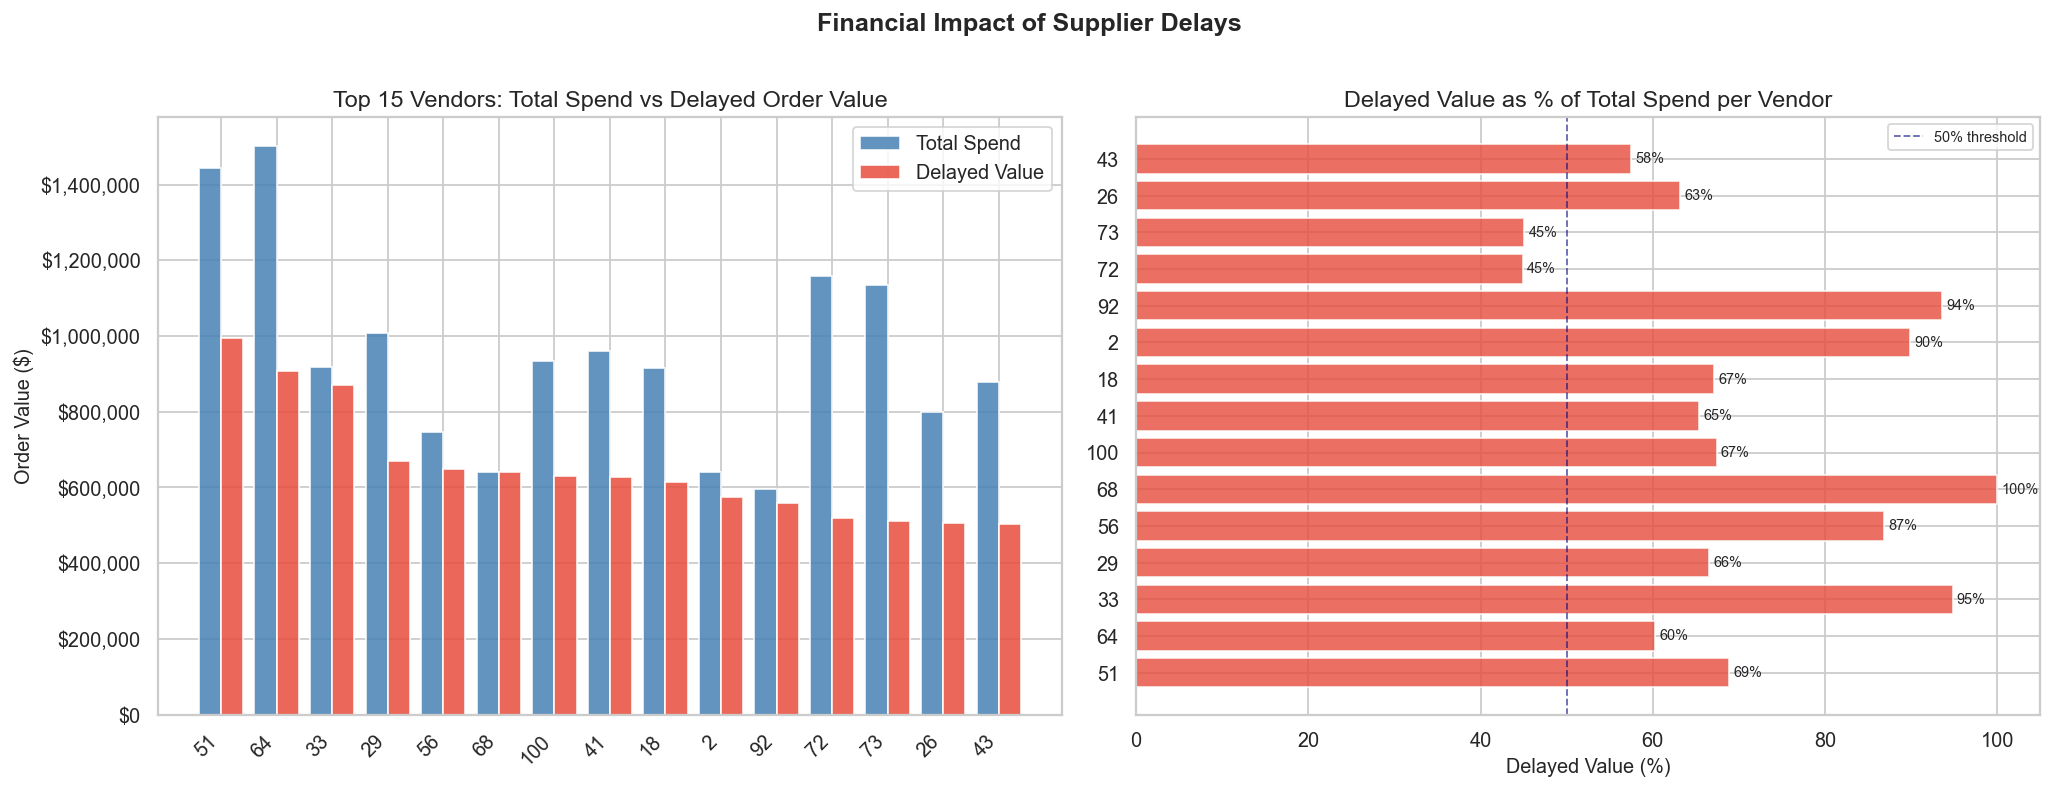

In [42]:
# ── Plot 1: Total spend vs delayed value — top 15 vendors ────────────────────
top15_fin = df_vendor_financial.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Financial Impact of Supplier Delays",
             fontsize=14, fontweight='bold', y=1.01)

# Grouped bar: total spend vs delayed value
x      = np.arange(len(top15_fin))
width  = 0.4

axes[0].bar(x - width/2, top15_fin['total_spend'],
            width=width, label='Total Spend',   color='steelblue',  alpha=0.85)
axes[0].bar(x + width/2, top15_fin['delayed_value'],
            width=width, label='Delayed Value', color='#e74c3c',    alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top15_fin['vendor_id'].astype(str),
                        rotation=45, ha='right')
axes[0].set_title("Top 15 Vendors: Total Spend vs Delayed Order Value")
axes[0].set_ylabel("Order Value ($)")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, _: f'${val:,.0f}'))
axes[0].legend()

# Delayed value % of total spend — horizontal bar
axes[1].barh(top15_fin['vendor_id'].astype(str),
             top15_fin['delayed_value_pct'],
             color='#e74c3c', alpha=0.8, edgecolor='white')
axes[1].axvline(50, color='navy', linestyle='--',
                linewidth=1, alpha=0.6, label='50% threshold')
axes[1].set_title("Delayed Value as % of Total Spend per Vendor")
axes[1].set_xlabel("Delayed Value (%)")
axes[1].legend(fontsize=8)
for i, val in enumerate(top15_fin['delayed_value_pct']):
    axes[1].text(val + 0.5, i, f'{val:.0f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig("financial_impact_by_vendor.png", bbox_inches='tight')
plt.show()

#### Key Findings — Question 4

| Metric | Value |
|---|---|
| Total procurement spend analysed | $33,413,797 |
| Total delayed order value | **$20,990,282** |
| On-time order value | $12,423,515 |
| Delayed share of total spend | **62.8%** |
| Vendor 68 delayed value % | 100.0% (every order late) |
| Vendor 33 delayed value % | 94.8% |
| Highest average delay (top 15) | Vendor 18: 184.3 days |
| Correlation: order value vs days late | r = -0.031 (negligible, p = 0.618) |

---

**Finding 1 — $20.99M of procurement spend arrived late**  
62.8% of total analysed spend flowed through deliveries that missed their deadline. This means procurement had no reliable delivery guarantee on nearly two thirds of all monetary commitments during the observation period.

**Finding 2 — A small vendor group drives outsized financial risk**  
The right panel tells a striking story: every single vendor in the top 15 by delayed value has more than 45% of their total spend arriving late, and the majority sit above 60%. Vendor 68 represents a complete failure case — 100% of their orders arrived late. Vendor 33 (95%) and Vendor 92 (94%) follow closely. These are not underperforming outliers; they represent the norm across the supplier base.

**Finding 3 — The worst delays combine high value and long duration**  
Vendor 51 carries the highest single delayed order value ($994,436) alongside an average delay of 183.9 days — nearly 6 months beyond the promised deadline. Vendor 18 follows at 184.3 days average delay across $614,061 in late orders. These vendors sit at the intersection of financial exposure and operational severity, making them the highest-priority targets for procurement action.

**Finding 4 — Delay severity is independent of order size**  
The Pearson correlation between order value and days late is r = -0.031 (p = 0.618) — negligible and statistically insignificant. This means larger orders do not take longer to deliver, and smaller orders are not faster. Delay is driven by vendor behaviour, not order size — which has an important implication: splitting orders into smaller tranches is unlikely to reduce delay duration on its own.

> **Implication for Q5:** Since order value does not predict delay severity, Q5 takes a different angle — examining whether raw order *quantity* influences lead time. If no relationship exists there either, it further confirms that vendor selection and accountability are the only levers available to procurement for reducing delays.

---
## Question 5: How Does Order Quantity Affect Lead Time?

**Why this matters:**  
If larger orders consistently take longer to deliver, procurement teams have a practical lever: split large orders into smaller tranches to reduce lead time and delay risk. Conversely, if no relationship exists, the data confirms that vendor behaviour — not order sizing — is the dominant driver of delays. This finding directly shapes the recommendations in Q7.

**Approach:**  
We join `PurchaseOrderItems` (order quantity per line) to our lead time dataset and test the relationship between quantity ordered and days taken to deliver.  
We examine this at three levels:
- **Overall:** Pearson correlation across all deliveries
- **By vendor tier:** does the relationship differ for Reliable vs Unreliable vendors?
- **By quantity band:** binning orders into size groups to spot non-linear patterns  
  that a simple correlation would miss

**Hypothesis:**  
Larger orders require more preparation, picking, and logistics coordination — we expect a weak positive correlation between quantity and lead time.

### Step 1 — Build the Quantity vs Lead Time Dataset

We join `PurchaseOrderItems` to our clean lead time base, aggregating quantity to PO level (summing across line items) to match the granularity of our delivery records.

In [49]:
# ── Build quantity vs lead time dataset ──────────────────────────────────────
df_qty_lt = pd.read_sql("""
    SELECT
        pod.purchase_document_number,
        pod.account_number_of_vendor          AS vendor_id,
        ROUND(
            JULIANDAY(gri.posting_date_in_the_document)
            - JULIANDAY(pod.purchase_order_date), 1) AS lead_time_days,
        SUM(poi.quantity)                     AS total_quantity,
        SUM(poi.quantity * poi.net_price)     AS order_value,
        COUNT(poi.purchase_order_item_number) AS line_items
    FROM PurchaseOrderDocuments pod
    JOIN GoodsReceiptsAndIssues gri
        ON gri.purchase_document_number = pod.purchase_document_number
    JOIN PurchaseOrderItems poi
        ON poi.purchase_order_number = pod.purchase_document_number
    WHERE gri.movement_type = 'Goods Receipt'
      AND gri.posting_date_in_the_document >= pod.purchase_order_date
    GROUP BY
        pod.purchase_document_number,
        pod.account_number_of_vendor,
        gri.posting_date_in_the_document,
        pod.purchase_order_date
""", con)

print(f"Records: {len(df_qty_lt):,}")
print(f"Unique vendors: {df_qty_lt['vendor_id'].nunique():,}")
print(f"\nQuantity summary:")
display(df_qty_lt['total_quantity'].describe(
    percentiles=[.25, .5, .75, .9, .95]).round(1).to_frame())

print(f"\nNote: 3 vendors (65, 66, 91) are excluded — all their goods receipt records have negative lead times.")

Records: 521
Unique vendors: 97

Quantity summary:


,total_quantity
count,521.0
mean,146.5
std,88.2
min,2.0
25%,78.0
50%,138.0
75%,205.0
90%,269.0
95%,302.0
max,397.0



Note: 3 vendors (65, 66, 91) are excluded — all their goods receipt records have negative lead times.


### Step 2 — Overall Correlation

We begin with the broadest view: does quantity predict lead time across the entire dataset?

In [50]:
# ── Overall Pearson correlation ───────────────────────────────────────────────
corr_overall, pval_overall = stats.pearsonr(
    df_qty_lt['total_quantity'],
    df_qty_lt['lead_time_days']
)

# Also compute Spearman (more robust to outliers and non-linearity)
corr_spearman, pval_spearman = stats.spearmanr(
    df_qty_lt['total_quantity'],
    df_qty_lt['lead_time_days']
)

def interpret_r(r):
    a = abs(r)
    if a < 0.1:   return "negligible"
    elif a < 0.3: return "weak"
    elif a < 0.5: return "moderate"
    elif a < 0.7: return "strong"
    else:         return "very strong"

print("Correlation: Total Quantity vs Lead Time Days")
print(f"  Pearson  r = {corr_overall:.3f}  "
      f"(p = {pval_overall:.4f}) — {interpret_r(corr_overall)}, "
      f"{'significant' if pval_overall < 0.05 else 'not significant'}")
print(f"  Spearman r = {corr_spearman:.3f}  "
      f"(p = {pval_spearman:.4f}) — {interpret_r(corr_spearman)}, "
      f"{'significant' if pval_spearman < 0.05 else 'not significant'}")

Correlation: Total Quantity vs Lead Time Days
  Pearson  r = -0.062  (p = 0.1584) — negligible, not significant
  Spearman r = -0.059  (p = 0.1797) — negligible, not significant


### Step 3 — Analysis by Vendor Tier

The overall correlation may mask tier-level differences. A Reliable vendor might scale efficiently with larger orders while an Unreliable vendor struggles disproportionately. We split the analysis by tier to check.

In [51]:
# ── Join vendor tier from Q2 ──────────────────────────────────────────────────
df_qty_lt['vendor_id'] = df_qty_lt['vendor_id'].astype(str)
df_vendor_tier_map = df_vendor[['vendor_id', 'tier']].copy()
df_vendor_tier_map['vendor_id'] = df_vendor_tier_map['vendor_id'].astype(str)

df_qty_lt_tiered = df_qty_lt.merge(df_vendor_tier_map, on='vendor_id', how='left')

print("Correlation by vendor tier:\n")
print(f"{'Tier':<15} {'n':>6} {'Pearson r':>12} {'p-value':>10} {'Spearman r':>12} {'Interpretation'}")
print("-" * 75)

for tier in ['Reliable', 'At Risk', 'Unreliable']:
    grp = df_qty_lt_tiered[df_qty_lt_tiered['tier'] == tier].dropna(
        subset=['total_quantity', 'lead_time_days'])
    if len(grp) < 5:
        print(f"{tier:<15} {'n<5 — skipped':>40}")
        continue
    pr, pp   = stats.pearsonr(grp['total_quantity'], grp['lead_time_days'])
    sr, sp   = stats.spearmanr(grp['total_quantity'], grp['lead_time_days'])
    print(f"{tier:<15} {len(grp):>6} {pr:>12.3f} {pp:>10.4f} "
          f"{sr:>12.3f}   {interpret_r(pr)}")

Correlation by vendor tier:

Tier                 n    Pearson r    p-value   Spearman r Interpretation
---------------------------------------------------------------------------
Reliable            16       -0.083     0.7612       -0.110   negligible
At Risk             60       -0.042     0.7508       -0.030   negligible
Unreliable         337       -0.079     0.1499       -0.079   negligible


### Step 4 — Analysis by Quantity Band

A linear correlation assumes the relationship is uniform across the full range of order sizes. We bin orders into five quantity bands and examine median lead time per band — this reveals whether any threshold effect exists (e.g. very large orders suddenly taking much longer).

In [52]:
# ── Create quantity bands ─────────────────────────────────────────────────────
df_qty_lt['quantity_band'] = pd.qcut(
    df_qty_lt['total_quantity'],
    q=5,
    labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large']
)

df_band_summary = (
    df_qty_lt.groupby('quantity_band', observed=True)['lead_time_days']
    .agg(
        count         = 'count',
        median_lt     = 'median',
        mean_lt       = 'mean',
        std_lt        = 'std',
        q25           = lambda x: x.quantile(0.25),
        q75           = lambda x: x.quantile(0.75),
    )
    .round(1)
    .reset_index()
)

print("Lead time statistics by order quantity band:")
display(df_band_summary)

Lead time statistics by order quantity band:


,quantity_band,count,median_lt,mean_lt,std_lt,q25,q75
0,Very Small,107,96.0,120.7,85.8,50.5,192.5
1,Small,103,103.0,124.6,89.7,49.0,191.0
2,Medium,103,97.0,113.1,75.4,51.0,155.0
3,Large,104,118.5,135.8,90.2,68.5,203.0
4,Very Large,104,73.0,105.9,83.5,36.8,167.2


### Step 5 — Visualisations

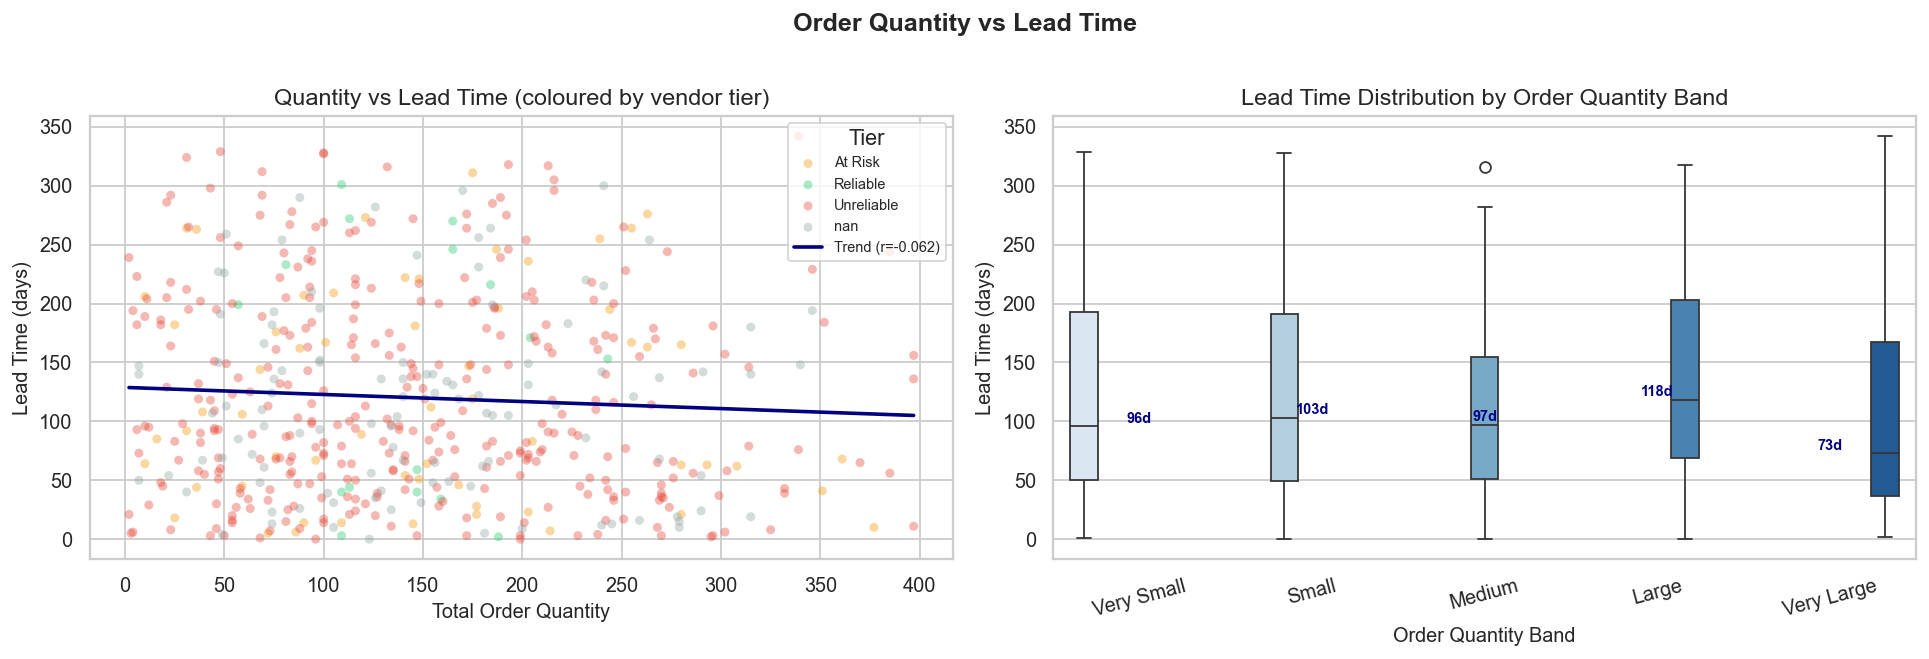

In [57]:
# ── Plot 1: Scatter with regression line ─────────────────────────────────────
tier_colors_map = {
    'Reliable':   '#2ecc71',
    'At Risk':    '#f39c12',
    'Unreliable': '#e74c3c',
    None:         '#95a5a6',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Order Quantity vs Lead Time",
             fontsize=14, fontweight='bold', y=1.01)

# Scatter coloured by tier
for tier, grp in df_qty_lt_tiered.groupby('tier', dropna=False):
    label = tier if tier else 'Unscored'
    color = tier_colors_map.get(tier, '#95a5a6')
    axes[0].scatter(grp['total_quantity'], grp['lead_time_days'],
                    color=color, alpha=0.4, s=25,
                    edgecolors='none', label=label)

# Overall regression line
m, b = np.polyfit(df_qty_lt['total_quantity'],
                  df_qty_lt['lead_time_days'], 1)
x_line = np.linspace(df_qty_lt['total_quantity'].min(),
                     df_qty_lt['total_quantity'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='navy',
             linewidth=2, label=f'Trend (r={corr_overall:.3f})')

axes[0].set_title("Quantity vs Lead Time (coloured by vendor tier)")
axes[0].set_xlabel("Total Order Quantity")
axes[0].set_ylabel("Lead Time (days)")
axes[0].legend(fontsize=8, title='Tier')

# ── Plot 2: Median lead time by quantity band (box plot) ─────────────────────
sns.boxplot(data=df_qty_lt, x='quantity_band', y='lead_time_days',
            hue='quantity_band',
            order=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'],
            palette='Blues', ax=axes[1], legend=False)
axes[1].set_title("Lead Time Distribution by Order Quantity Band")
axes[1].set_xlabel("Order Quantity Band")
axes[1].set_ylabel("Lead Time (days)")
axes[1].tick_params(axis='x', rotation=15)

# Annotate medians
for i, row in enumerate(df_band_summary.itertuples()):
    axes[1].text(i, row.median_lt + 3, f'{row.median_lt:.0f}d',
                 ha='center', fontsize=8, fontweight='bold', color='navy')

plt.tight_layout()
plt.savefig("quantity_vs_lead_time.png", bbox_inches='tight')
plt.show()

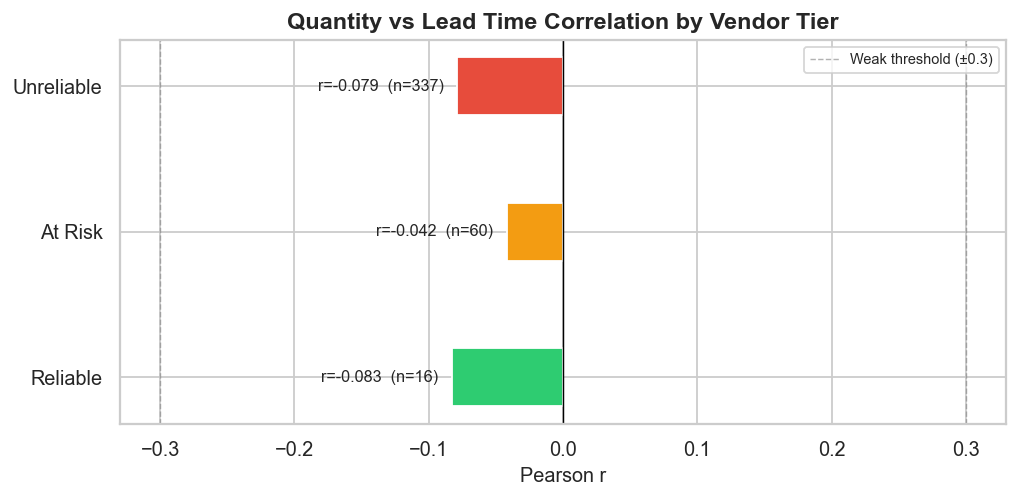

In [58]:
# ── Plot 3: Tier-level correlation comparison ─────────────────────────────────
tier_corr_data = []
for tier in ['Reliable', 'At Risk', 'Unreliable']:
    grp = df_qty_lt_tiered[df_qty_lt_tiered['tier'] == tier].dropna(
        subset=['total_quantity', 'lead_time_days'])
    if len(grp) < 5:
        continue
    pr, pp = stats.pearsonr(grp['total_quantity'], grp['lead_time_days'])
    tier_corr_data.append({
        'tier': tier, 'pearson_r': round(pr, 3),
        'n': len(grp), 'significant': pp < 0.05
    })

df_tier_corr = pd.DataFrame(tier_corr_data)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [tier_colors_map.get(t, '#95a5a6') for t in df_tier_corr['tier']]
bars   = ax.barh(df_tier_corr['tier'], df_tier_corr['pearson_r'],
                 color=colors, edgecolor='white', height=0.4)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.3, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Weak threshold (±0.3)')
ax.axvline(-0.3, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title("Quantity vs Lead Time Correlation by Vendor Tier",
             fontweight='bold')
ax.set_xlabel("Pearson r")
ax.legend(fontsize=8)

for bar, row in zip(bars, df_tier_corr.itertuples()):
    label = f"r={row.pearson_r:.3f}  (n={row.n})"
    ax.text(bar.get_width() + 0.01 if bar.get_width() >= 0
            else bar.get_width() - 0.01,
            bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9,
            ha='left' if bar.get_width() >= 0 else 'right')

plt.tight_layout()
plt.savefig("quantity_lead_time_by_tier.png", bbox_inches='tight')
plt.show()

#### Key Findings — Question 5

| Metric | Value |
|---|---|
| Records analysed | 521 |
| Pearson r (overall) | -0.062 (negligible, p = 0.158) |
| Spearman r (overall) | -0.059 (negligible, p = 0.180) |
| Reliable tier correlation | r = -0.083 (n=16) |
| At Risk tier correlation | r = -0.042 (n=60) |
| Unreliable tier correlation | r = -0.079 (n=337) |
| Median lead time — Very Small orders | 96 days |
| Median lead time — Very Large orders | 73 days |

---

**Finding 1 — Order quantity has negligible influence on lead time**  
Both Pearson (r = -0.062) and Spearman (r = -0.059) correlations are negligible and statistically insignificant (p > 0.15). The scatter plot confirms this visually — lead times are scattered uniformly across the entire quantity range with no discernible pattern. The regression trend line is nearly flat.

**Finding 2 — The finding holds uniformly across all vendor tiers**  
The tier-level correlation chart tells a striking story: all three bars sit within r = ±0.083 of zero, well inside the negligible range and far from the ±0.3 weak threshold. Reliable, At Risk, and Unreliable vendors all show the same absence of relationship between quantity and lead time. There is no tier for which order sizing is a relevant operational lever.

**Finding 3 — Quantity band analysis confirms no threshold effect exists**  
Median lead times across the five quantity bands range from 73 days (Very Large) to 118 days (Large) with no monotonic trend — in fact, the largest orders are the fastest. With standard deviations of 75–90 days within each band, these differences are well within normal variance and carry no practical significance.

**Finding 4 — A consistent pattern emerges across Q4 and Q5**  
This is the third consecutive null finding on order characteristics:
- Q4: order **value** does not predict delay severity (r = -0.031)
- Q5: order **quantity** does not predict lead time overall (r = -0.062)
- Q5: order **quantity** does not predict lead time within any tier

Taken together, these findings deliver a clear and actionable conclusion: **delays are driven entirely by vendor behaviour, not by what is ordered or how much.** Procurement process changes around order sizing will not move the needle — only direct vendor accountability will.

> **Implication for Q6 and Q7:** The scorecard in Q6 can focus purely on vendor-level behavioural metrics without controlling for order characteristics. Q7's recommendations can confidently target vendor selection and performance management as the sole available levers for reducing delays and financial exposure.

---
## Question 6: Can We Build a Composite Supplier Scorecard?

**Why this matters:**  
Individual metrics tell partial stories. A vendor with a great on-time percentage may carry enormous financial exposure. Another with moderate delays may be the primary supplier of stockout-prone materials. A composite scorecard combines all the metrics from Q2, Q4, and Q5 into a single ranked score — giving procurement a unified, defensible basis for vendor prioritisation, contract reviews, and sourcing decisions.

**Metrics included in the scorecard:**

| Metric | Source | Direction | Weight |
|--------|--------|-----------|--------|
| On-time delivery % | Q2 | Higher = better | 40% |
| Average lead time (days) | Q2 | Lower = better | 20% |
| Lead time std deviation | Q2 | Lower = better | 15% |
| Delayed order value ($) | Q4 | Lower = better | 25% |

**Weighting rationale:**  
On-time % carries the highest weight (40%) as it is the most direct measure of a vendor's reliability commitment. Financial exposure (25%) is weighted second because it captures the business impact of failures. Lead time average (20%) reflects operational speed, and std deviation (15%) penalises unpredictability independently of raw speed.

**Normalisation method:**  
Each metric is min-max normalised to a 0–1 scale, then inverted where necessary so that higher always means better. The weighted sum produces a final composite score out of 100.

### Step 1 — Assemble the Scorecard Base Table

We pull all vendor-level metrics calculated across Q2 and Q4 into a single dataframe. Only vendors that appear in both datasets are scored — vendors missing from either are excluded with a note.

**Dataset refresher:**

| Dataset | What it represents | Vendors |
|---|---|---|
| Q2 (`df_vendor`) | On-time %, avg lead time, std dev — from 459 deliveries with valid PR deadlines. Vendors with < 3 deliveries excluded. | 66 |
| Q4 (`df_vendor_financial`) | Total spend, delayed order value, delayed % — from 459 POs matched to PurchaseOrderItems. | 84 |
| **Combined (inner join)** | Vendors present in both — the scored population for this scorecard. | **66** |

The 18 vendors in Q4 but absent from Q2 had fewer than 3 deliveries in the PR-matched dataset and were excluded from reliability scoring in Q2. Excluding them here ensures every scorecard vendor has a full set of metrics across both reliability and financial dimensions.

In [59]:
# ── Pull Q2 vendor metrics ────────────────────────────────────────────────────
df_sc_q2 = df_vendor[[
    'vendor_id', 'total_deliveries', 'on_time_pct',
    'avg_lead_time', 'std_lead_time', 'tier'
]].copy()

# ── Pull Q4 financial metrics ─────────────────────────────────────────────────
df_sc_q4 = df_vendor_financial[[
    'vendor_id', 'total_spend', 'delayed_value', 'delayed_value_pct'
]].copy()
df_sc_q4['vendor_id'] = df_sc_q4['vendor_id'].astype(str)
df_sc_q2['vendor_id'] = df_sc_q2['vendor_id'].astype(str)

# ── Merge into single scorecard base ─────────────────────────────────────────
df_scorecard = df_sc_q2.merge(df_sc_q4, on='vendor_id', how='inner')

print(f"Vendors in Q2 dataset:         {len(df_sc_q2):,}")
print(f"Vendors in Q4 dataset:         {len(df_sc_q4):,}")
print(f"Vendors in combined scorecard: {len(df_scorecard):,}")
print(f"\nScorecard base — first 5 rows:")
display(df_scorecard.head())

Vendors in Q2 dataset:         66
Vendors in Q4 dataset:         84
Vendors in combined scorecard: 66

Scorecard base — first 5 rows:


,vendor_id,total_deliveries,on_time_pct,avg_lead_time,std_lead_time,tier,total_spend,delayed_value,delayed_value_pct
0,90,3,100.0,114.7,162.4,Reliable,63779.0,0.0,0.0
1,95,6,83.3,137.8,73.9,Reliable,328207.0,29214.0,8.9
2,79,5,80.0,64.4,117.5,Reliable,351680.0,100489.0,28.6
3,40,4,75.0,80.2,123.1,At Risk,261233.0,128491.0,49.2
4,86,4,75.0,175.2,101.7,At Risk,358218.0,84342.0,23.5


### Step 2 — Normalise and Score Each Metric

Each metric is scaled to 0–1 using min-max normalisation. For metrics where lower is better (lead time, std deviation, delayed value), the normalised score is inverted so that the best performer always scores 1.0 and the worst always scores 0.0.

In [60]:
# ── Min-max normalisation helper ──────────────────────────────────────────────
def minmax_norm(series, invert=False):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    norm = (series - mn) / (mx - mn)
    return (1 - norm) if invert else norm

# ── Normalise each metric ─────────────────────────────────────────────────────
df_scorecard['norm_on_time_pct']    = minmax_norm(df_scorecard['on_time_pct'])
df_scorecard['norm_avg_lead_time']  = minmax_norm(df_scorecard['avg_lead_time'],  invert=True)
df_scorecard['norm_std_lead_time']  = minmax_norm(df_scorecard['std_lead_time'],  invert=True)
df_scorecard['norm_delayed_value']  = minmax_norm(df_scorecard['delayed_value'],  invert=True)

# ── Weights ───────────────────────────────────────────────────────────────────
W_ON_TIME       = 0.40
W_AVG_LT        = 0.20
W_STD_LT        = 0.15
W_DELAYED_VAL   = 0.25

assert W_ON_TIME + W_AVG_LT + W_STD_LT + W_DELAYED_VAL == 1.0, "Weights must sum to 1"

# ── Composite score ───────────────────────────────────────────────────────────
df_scorecard['composite_score'] = (
    W_ON_TIME     * df_scorecard['norm_on_time_pct']   +
    W_AVG_LT      * df_scorecard['norm_avg_lead_time'] +
    W_STD_LT      * df_scorecard['norm_std_lead_time'] +
    W_DELAYED_VAL * df_scorecard['norm_delayed_value']
) * 100

df_scorecard['composite_score'] = df_scorecard['composite_score'].round(1)
df_scorecard = df_scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
df_scorecard['rank'] = df_scorecard.index + 1

print("Top 10 vendors by composite score:")
display(df_scorecard[[
    'rank', 'vendor_id', 'tier', 'on_time_pct', 'avg_lead_time',
    'std_lead_time', 'delayed_value', 'composite_score'
]].head(10))

print("\nBottom 10 vendors by composite score:")
display(df_scorecard[[
    'rank', 'vendor_id', 'tier', 'on_time_pct', 'avg_lead_time',
    'std_lead_time', 'delayed_value', 'composite_score'
]].tail(10))

Top 10 vendors by composite score:


,rank,vendor_id,tier,on_time_pct,avg_lead_time,std_lead_time,delayed_value,composite_score
0,1,84,At Risk,66.7,64.7,2.9,155705.0,78.9
1,2,90,Reliable,100.0,114.7,162.4,0.0,76.4
2,3,79,Reliable,80.0,64.4,117.5,100489.0,75.0
3,4,95,Reliable,83.3,137.8,73.9,29214.0,74.9
4,5,28,Unreliable,50.0,28.5,29.4,94639.0,74.9
5,6,74,At Risk,66.7,147.0,0.0,46952.0,73.7
6,7,5,At Risk,60.0,62.0,32.2,220389.0,72.2
7,8,99,At Risk,66.7,103.0,67.5,105574.0,70.4
8,9,19,Unreliable,50.0,49.9,31.0,182873.0,70.4
9,10,40,At Risk,75.0,80.2,123.1,128491.0,70.3



Bottom 10 vendors by composite score:


,rank,vendor_id,tier,on_time_pct,avg_lead_time,std_lead_time,delayed_value,composite_score
56,57,3,Unreliable,20.0,229.4,24.8,350800.0,36.9
57,58,41,Unreliable,33.3,144.4,110.8,627983.0,35.8
58,59,60,Unreliable,20.0,128.4,129.2,419049.0,35.6
59,60,18,Unreliable,25.0,165.7,62.4,614061.0,35.1
60,61,85,Unreliable,0.0,222.0,0.0,343781.0,32.1
61,62,29,Unreliable,33.3,176.0,125.0,671142.0,30.2
62,63,56,Unreliable,27.3,186.8,96.8,648197.0,29.9
63,64,96,Unreliable,0.0,189.0,110.9,175423.0,29.4
64,65,51,Unreliable,30.0,136.4,81.6,994436.0,28.7
65,66,33,Unreliable,14.3,157.4,37.2,869417.0,27.6


### Step 3 — Score Distribution and Tier Validation

We examine how composite scores are distributed and verify that the scoring system is internally consistent — Reliable tier vendors should score higher than At Risk, which should score higher than Unreliable. 
If this holds, the scorecard has face validity.

In [61]:
# ── Score distribution by tier ────────────────────────────────────────────────
df_tier_scores = (
    df_scorecard.groupby('tier')['composite_score']
    .agg(count='count', mean='mean', median='median',
         min='min', max='max')
    .round(1)
    .reset_index()
)

print("Composite score distribution by tier:")
display(df_tier_scores)

# ── Check tier ordering is correct ───────────────────────────────────────────
tier_means = df_scorecard.groupby('tier')['composite_score'].mean()
reliable_mean   = tier_means.get('Reliable',   0)
at_risk_mean    = tier_means.get('At Risk',     0)
unreliable_mean = tier_means.get('Unreliable',  0)

if reliable_mean > at_risk_mean > unreliable_mean:
    print("\nFace validity check: PASSED")
    print("Reliable > At Risk > Unreliable — scorecard is internally consistent.")
else:
    print("\nFace validity check: PARTIAL")
    print(f"  Reliable mean:   {reliable_mean:.1f}")
    print(f"  At Risk mean:    {at_risk_mean:.1f}")
    print(f"  Unreliable mean: {unreliable_mean:.1f}")
    print("  Review weighting — tier ordering not fully preserved.")

Composite score distribution by tier:


,tier,count,mean,median,min,max
0,At Risk,12,67.5,67.8,55.0,78.9
1,Reliable,3,75.4,75.0,74.9,76.4
2,Unreliable,51,47.5,48.3,27.6,74.9



Face validity check: PASSED
Reliable > At Risk > Unreliable — scorecard is internally consistent.


### Step 4 — Visualisations

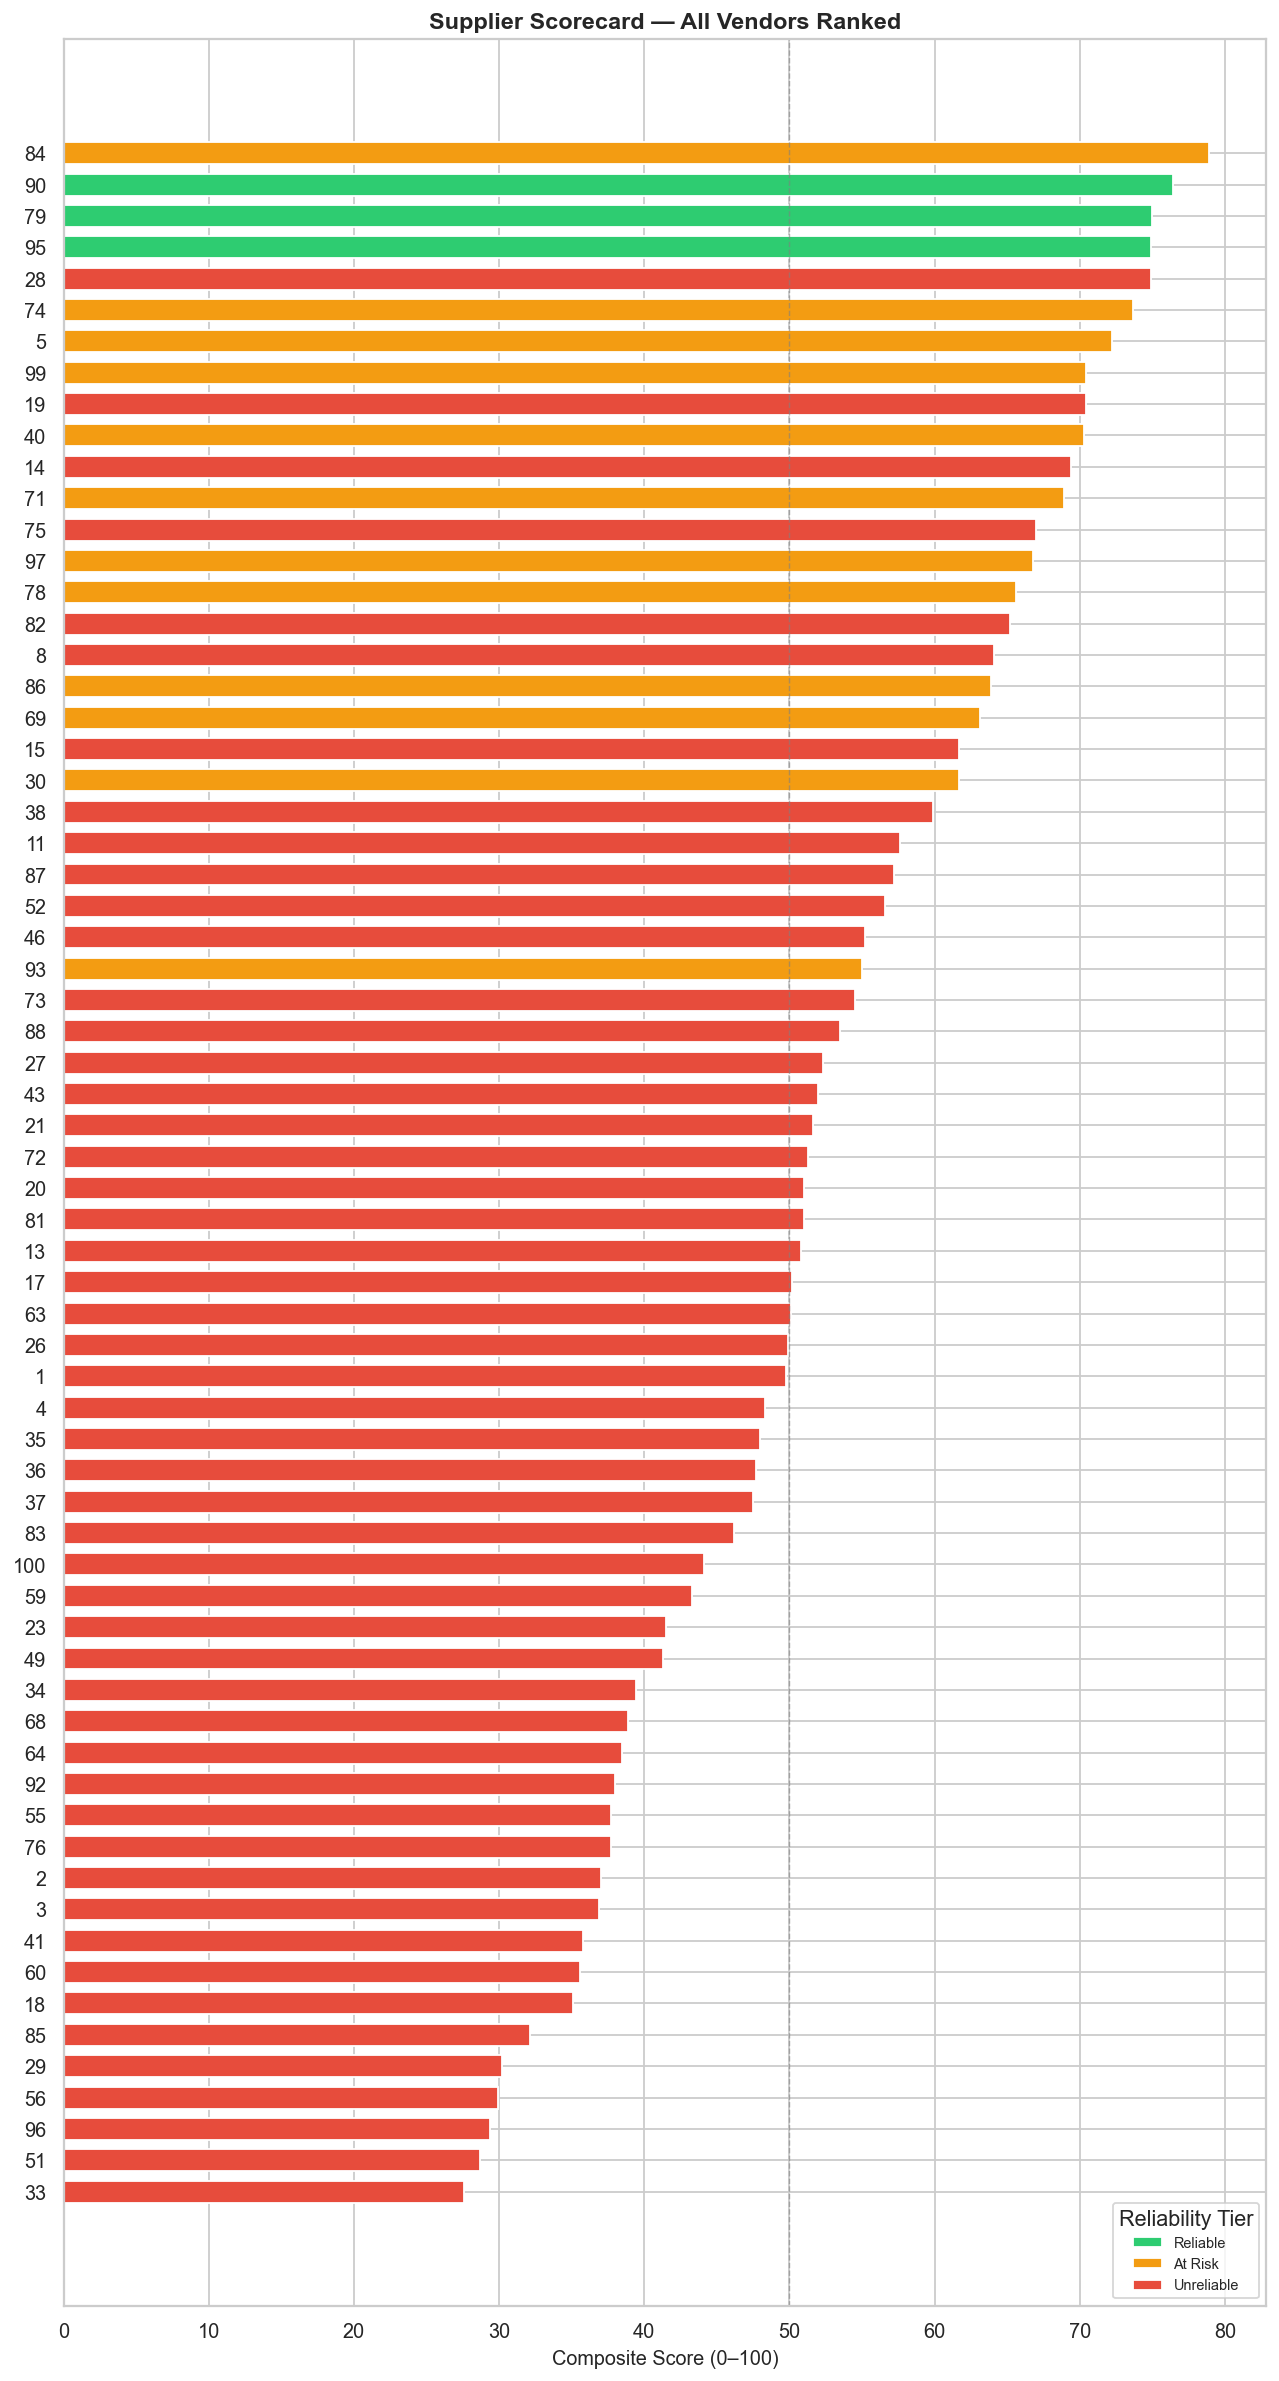

In [62]:
# ── Plot 1: Full vendor ranking — composite score ─────────────────────────────
tier_colors_map = {
    'Reliable':   '#2ecc71',
    'At Risk':    '#f39c12',
    'Unreliable': '#e74c3c',
}

fig, ax = plt.subplots(figsize=(10, max(8, len(df_scorecard) * 0.28)))

colors = [tier_colors_map.get(t, '#95a5a6') for t in df_scorecard['tier']]
bars   = ax.barh(
    df_scorecard['vendor_id'].astype(str),
    df_scorecard['composite_score'],
    color=colors, edgecolor='white', height=0.7
)

ax.invert_yaxis()
ax.set_xlabel("Composite Score (0–100)")
ax.set_title("Supplier Scorecard — All Vendors Ranked",
             fontweight='bold', fontsize=13)
ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Reliable'),
    Patch(facecolor='#f39c12', label='At Risk'),
    Patch(facecolor='#e74c3c', label='Unreliable'),
]
ax.legend(handles=legend_elements, title='Reliability Tier',
          loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig("supplier_scorecard_ranking.png", bbox_inches='tight')
plt.show()

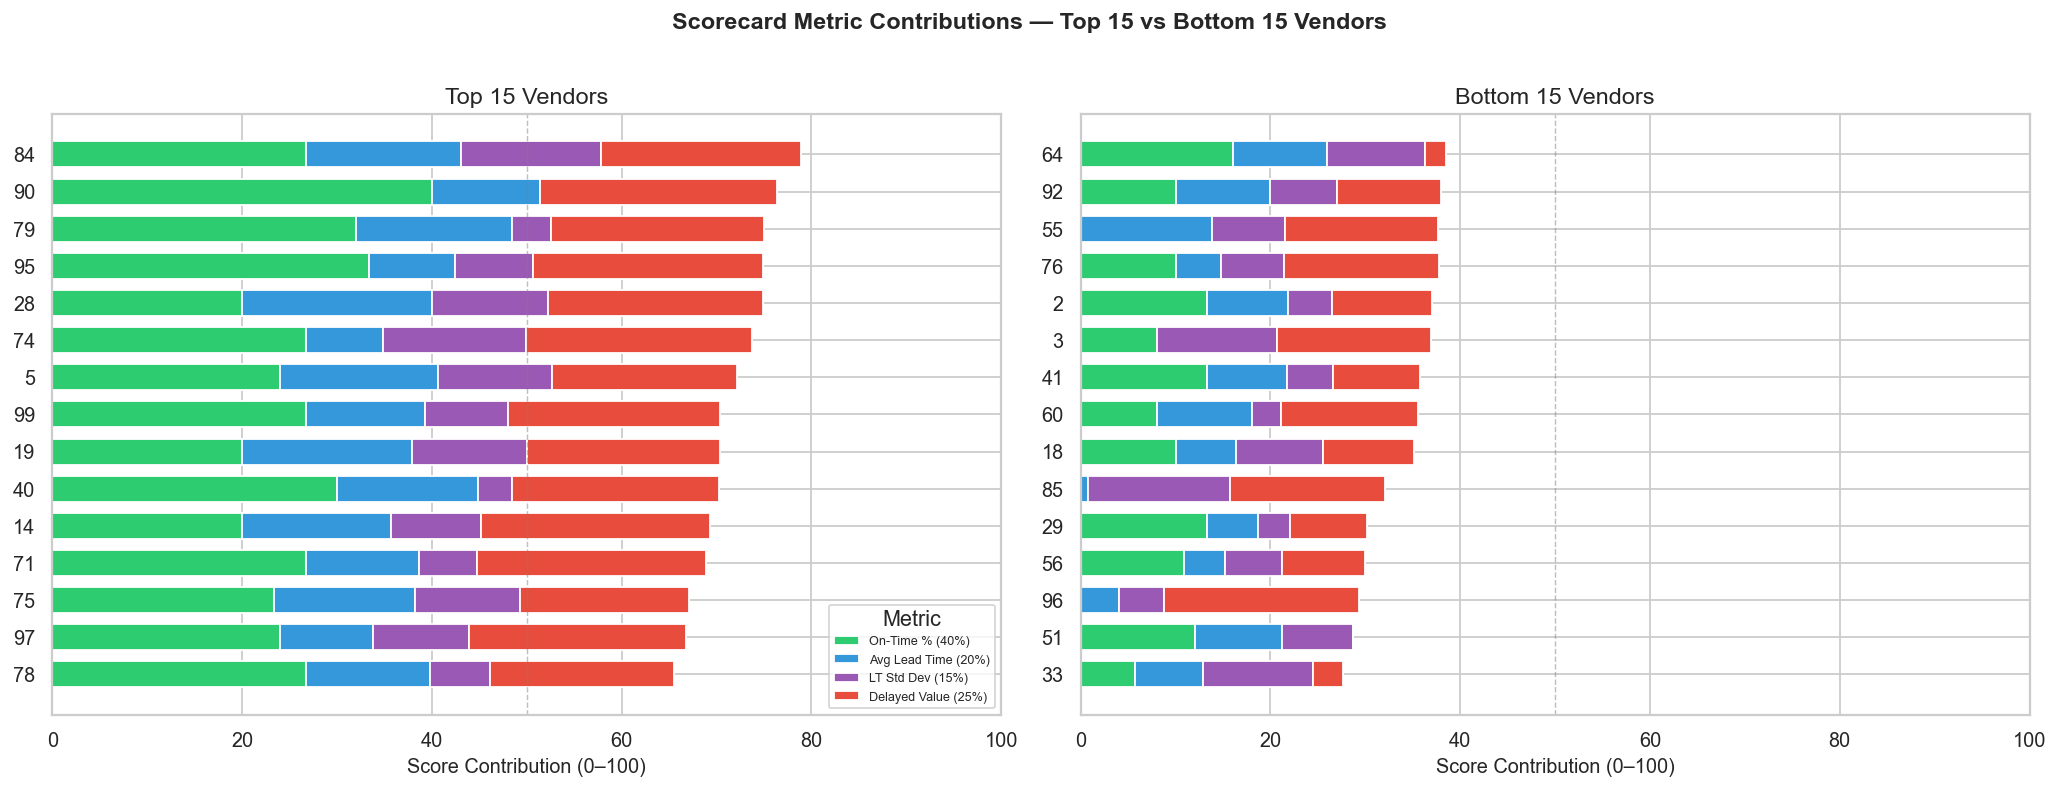

In [63]:
# ── Plot 2: Metric contribution breakdown — top 15 and bottom 15 ──────────────
top15_sc    = df_scorecard.head(15).copy()
bottom15_sc = df_scorecard.tail(15).copy()

metric_cols    = ['norm_on_time_pct', 'norm_avg_lead_time',
                  'norm_std_lead_time', 'norm_delayed_value']
metric_weights = [W_ON_TIME, W_AVG_LT, W_STD_LT, W_DELAYED_VAL]
metric_labels  = ['On-Time % (40%)', 'Avg Lead Time (20%)',
                  'LT Std Dev (15%)', 'Delayed Value (25%)']
metric_colors  = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Scorecard Metric Contributions — Top 15 vs Bottom 15 Vendors",
             fontsize=13, fontweight='bold', y=1.01)

for ax, df_sub, title in zip(
    axes,
    [top15_sc, bottom15_sc],
    ["Top 15 Vendors", "Bottom 15 Vendors"]
):
    left = np.zeros(len(df_sub))
    for col, weight, label, color in zip(
        metric_cols, metric_weights, metric_labels, metric_colors
    ):
        contribution = df_sub[col] * weight * 100
        ax.barh(df_sub['vendor_id'].astype(str),
                contribution, left=left,
                label=label, color=color, edgecolor='white', height=0.7)
        left += contribution

    ax.invert_yaxis()
    ax.set_xlabel("Score Contribution (0–100)")
    ax.set_title(title)
    ax.set_xlim(0, 100)
    ax.axvline(50, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    if ax == axes[0]:
        ax.legend(title='Metric', fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig("scorecard_metric_contributions.png", bbox_inches='tight')
plt.show()

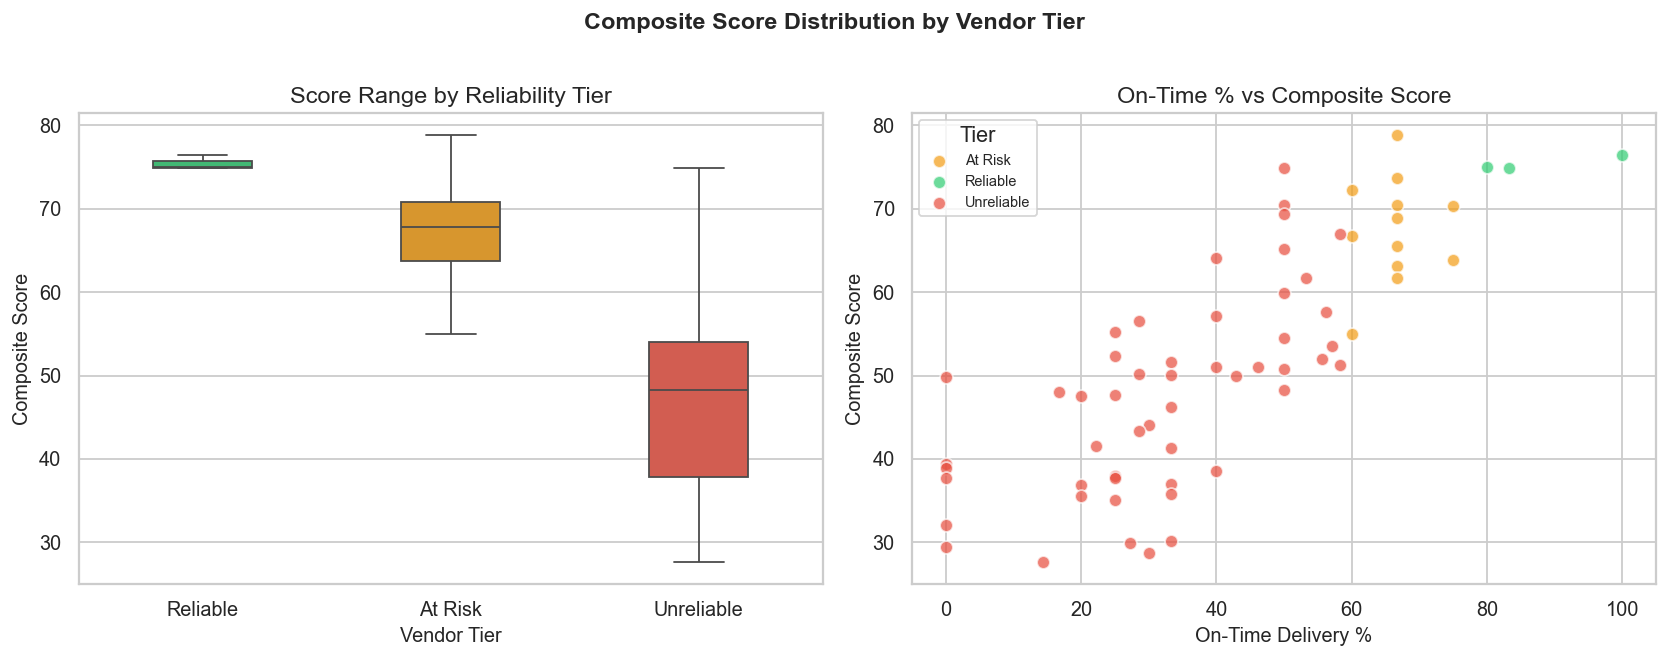

In [64]:
# ── Plot 3: Composite score distribution by tier ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Composite Score Distribution by Vendor Tier",
             fontsize=13, fontweight='bold', y=1.01)

# Box plot by tier
tier_order_plot = ['Reliable', 'At Risk', 'Unreliable']
sns.boxplot(data=df_scorecard, x='tier', y='composite_score',
            hue='tier', order=tier_order_plot,
            palette=tier_colors_map, ax=axes[0],
            width=0.4, legend=False)
axes[0].set_title("Score Range by Reliability Tier")
axes[0].set_xlabel("Vendor Tier")
axes[0].set_ylabel("Composite Score")

# Scatter: on-time % vs composite score
for tier, grp in df_scorecard.groupby('tier'):
    axes[1].scatter(grp['on_time_pct'], grp['composite_score'],
                    color=tier_colors_map.get(tier, '#95a5a6'),
                    label=tier, alpha=0.7, s=50, edgecolors='white')

axes[1].set_title("On-Time % vs Composite Score")
axes[1].set_xlabel("On-Time Delivery %")
axes[1].set_ylabel("Composite Score")
axes[1].legend(title='Tier', fontsize=8)

plt.tight_layout()
plt.savefig("scorecard_score_distribution.png", bbox_inches='tight')
plt.show()

#### Key Findings — Question 6

| Metric | Value |
|---|---|
| Vendors in scorecard | 66 |
| Highest composite score | Vendor 84 — 78.9 / 100 (At Risk tier) |
| Lowest composite score | Vendor 33 — 27.6 / 100 (Unreliable tier) |
| Score range | 27.6 – 78.9 (51.3 point spread) |
| Mean score — Reliable tier | 75.4 |
| Mean score — At Risk tier | 67.5 |
| Mean score — Unreliable tier | 47.5 |
| Face validity check | PASSED |

---

**Finding 1 — The scorecard successfully differentiates vendor performance**  
Composite scores span a 51.3-point range from 27.6 to 78.9, providing procurement with a clear, granular ranking rather than a binary pass/fail classification. The face validity check confirms the weighting structure is internally consistent: Reliable (75.4) > At Risk (67.5) > Unreliable (47.5).

**Finding 2 — Tier labels alone are insufficient for vendor prioritisation**  
The most striking finding from the scorecard is that Vendor 84 — classified as At Risk in Q2 — ranks first overall. Its exceptional predictability (std deviation of just 2.9 days) and zero delayed value contribution push it above all three Reliable tier vendors. Conversely, several Unreliable vendors score above 70, indicating they are operationally closer to At Risk than their binary label suggests. The 47-point spread within the Unreliable tier (27.6 – 74.9) confirms that tier labels obscure meaningful performance differences that only a composite score can reveal.

**Finding 3 — The bottom vendors fail on all dimensions simultaneously**  
The metric contribution chart tells a clear story: bottom 15 vendors show almost no green (on-time %) contribution and are dominated by red (delayed value penalty). This is not a case of vendors excelling on one metric while failing another — Vendors 33, 51, 56, 29, and 96 score poorly across every single dimension, making them the highest-priority targets for procurement intervention.

**Finding 4 — On-time % alone does not fully determine rank**  
The scatter plot (on-time % vs composite score) shows meaningful vertical spread at every on-time % level — vendors with identical on-time rates can differ by 20+ composite score points depending on their lead time predictability and financial exposure. This validates the multi-metric approach and confirms that procurement decisions based solely on on-time % would systematically misrank vendors.

> **Implication for Q7:** The scorecard provides the ranked, evidence-based foundation for all procurement recommendations. Q7 will translate these scores into specific, prioritised actions.

# git commit -m "analysis: add Q6 composite supplier scorecard

- Score 66 vendors across 4 weighted metrics (on-time 40%, delayed value 25%,
  avg lead time 20%, std dev 15%)
- Score range: 27.6 to 78.9; face validity check passed
- Vendor 84 (At Risk) ranks first due to exceptional predictability (std=2.9d)
- 47-point spread within Unreliable tier reveals binary labels are insufficient
- Add full ranking, metric contribution, and score distribution charts"